# Paper agent baseline

Minimal single-agent baseline imported from `urbanomy.methods.agent`.


In [1]:
from urbanomy.methods.agent import init_llm
import pandas as pd

llm = init_llm("deepseek/deepseek-v4-flash")


In [2]:
from urbanomy.methods.agent import SingleAgentBaseline

task = "Город Санкт-Петербург. � азработай план уплотнения городского центра."

baseline = SingleAgentBaseline(llm=llm)
state = baseline.invoke_state(task)


In [4]:
print(state["output"])


Санкт-Петербург — уникальный случай. Его исторический центр — объект Всемирного наследия ЮНЕСКО (и охранная зона строжайшего регулирования). Прямое «уплотнение» (снос исторических зданий и встройка новых высоток) здесь **категорически запрещено** законодательством РФ и международными обязательствами.

Поэтому под **«уплотнением»** в контексте СПб понимается не увеличение этажности, а **повышение интенсивности использования территории (реновация)** без нарушения градостроительных регламентов.

Вот реалистичный план, ориентированный на деловой и культурный центр в границах исторической застройки.

---

### I. Анализ текущей ситуации (Проблематика)
1.  **Деиндустриализация и субурбанизация:** Центр теряет постоянное население (жилье переводится в офисы и хостелы). Вечером — «вымерший» центр.
2.  **Износ фонда:** ~40% зданий в центре (дореволюционные доходные дома) имеют высокий износ. Капитальный ремонт затруднен статусом памятников.
3.  **Транспортный коллапс:** Узкие улицы не справляютс

In [4]:
# state["log"]


In [ ]:
import geopandas as gpd

basline_blocks = gpd.read_file('data/traning_data/gatchina_baseline.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,id,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [4]:
basline_blocks.loc[142]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                              1568.375787
build_floor_area                                            1568.375787
living_area                                                 1202.729596
non_living_area                                              365.646192
population                                                      

In [7]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('/Users/andreyfeduhin/Urbanomy-data/data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [8]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [9]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [10]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [10]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [11]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,id,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,1,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,2,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,3,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,4,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


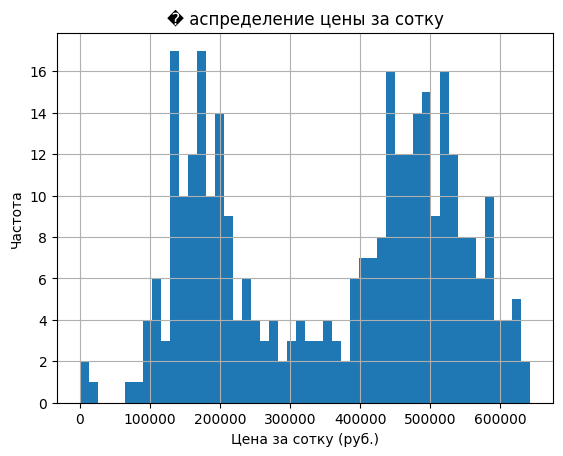

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("� аспределение цены за сотку")
plt.show()



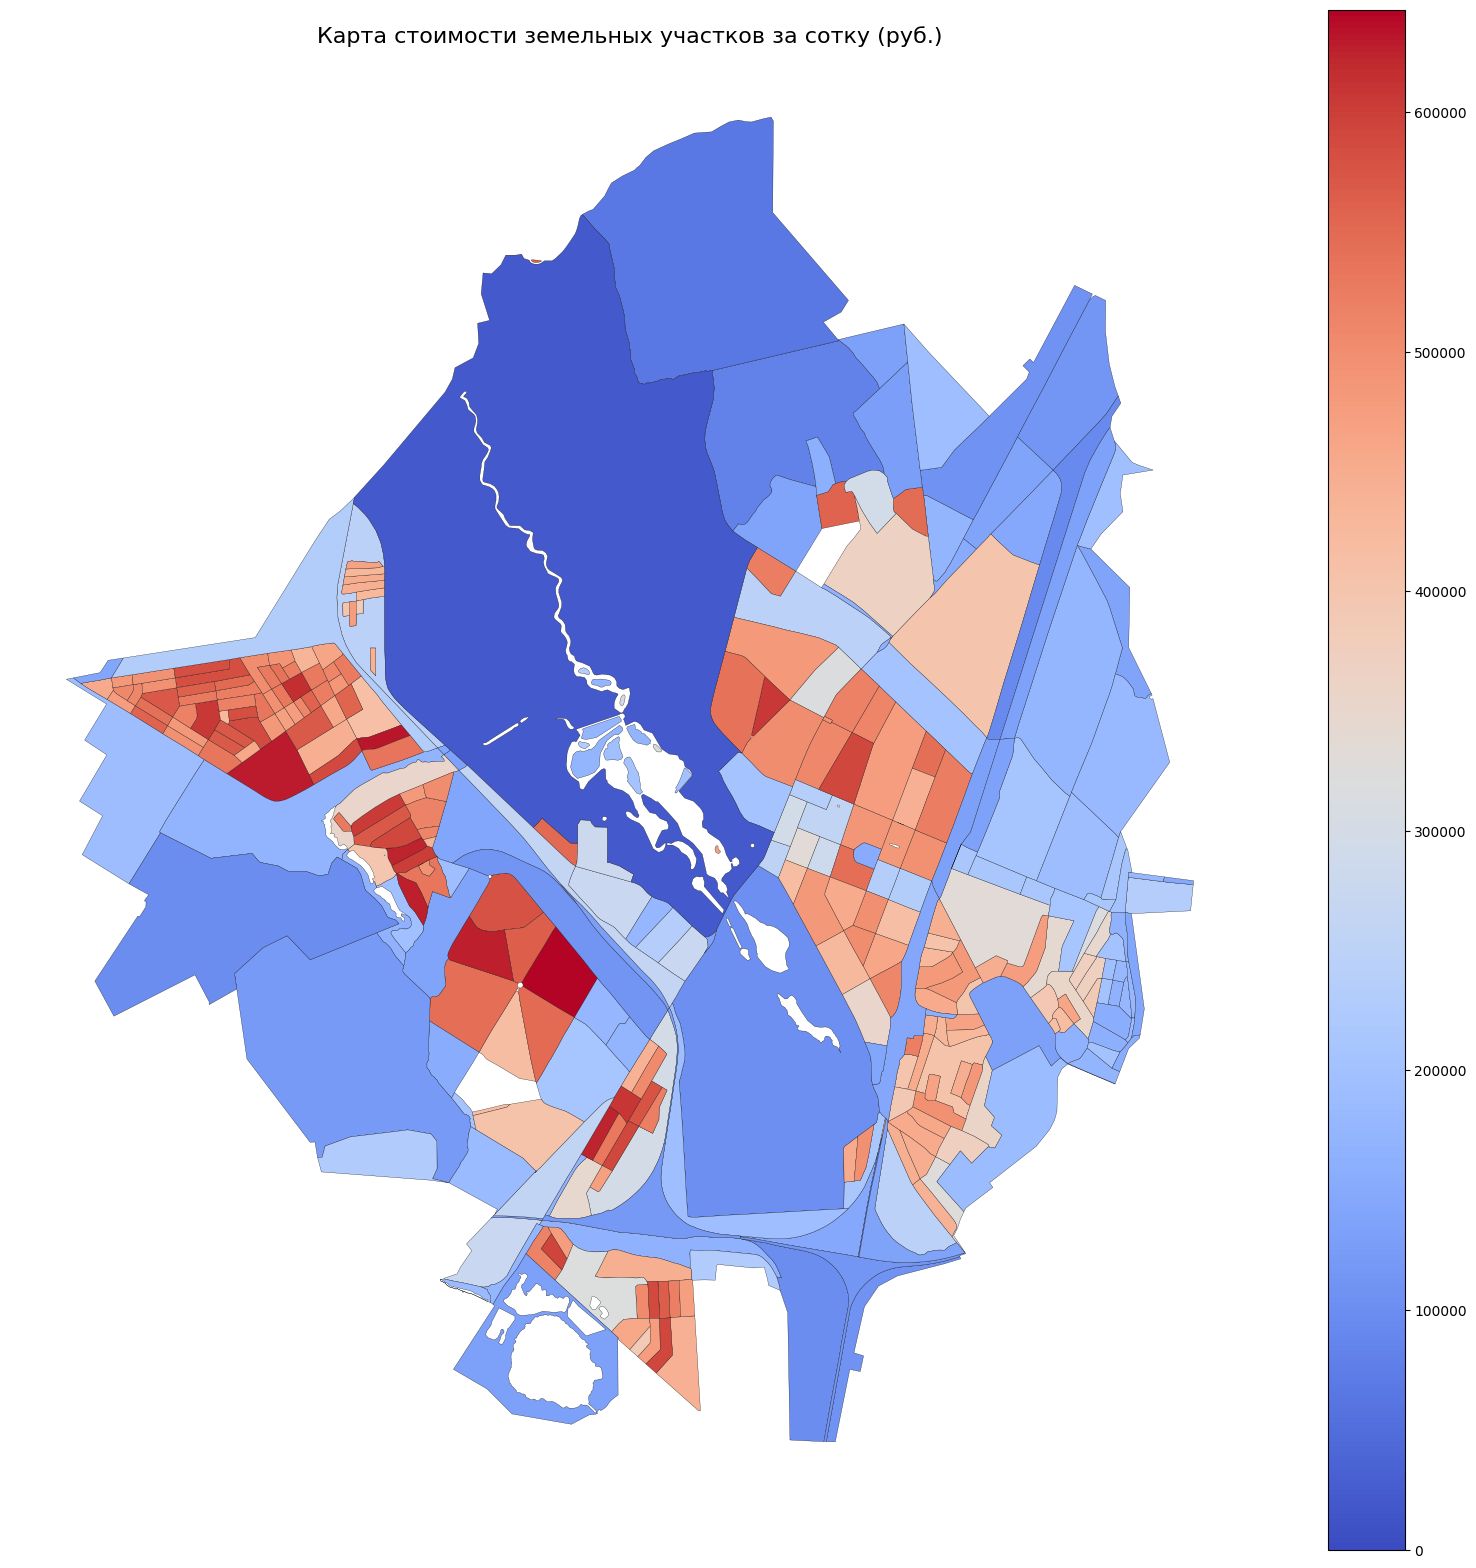

In [13]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

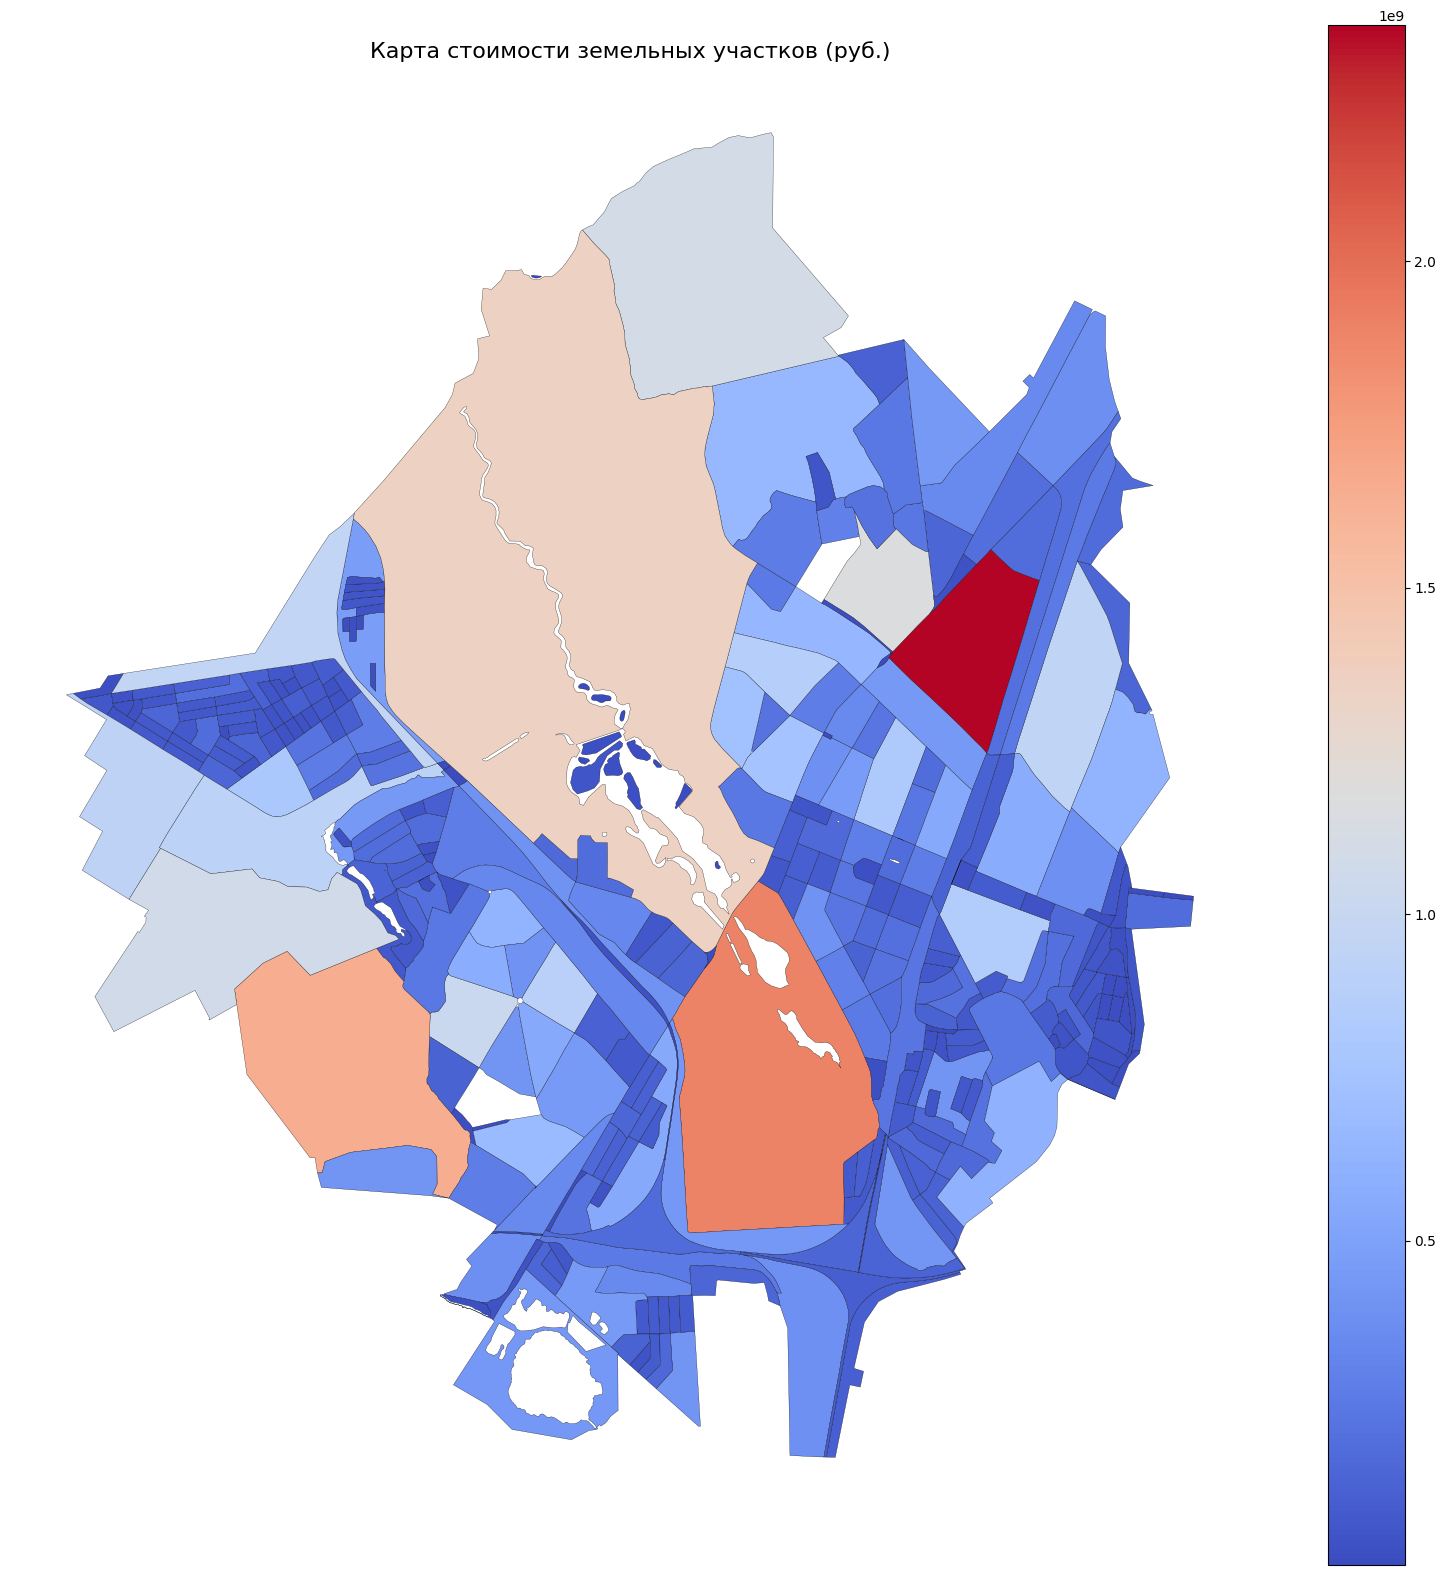

In [14]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [15]:
blocks_clean["id"] = blocks_clean.index

In [16]:
target_id = 86

/var/folders/yl/0swqblhn58d982w93b_6pg1w0000gn/T/ipykernel_10177/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


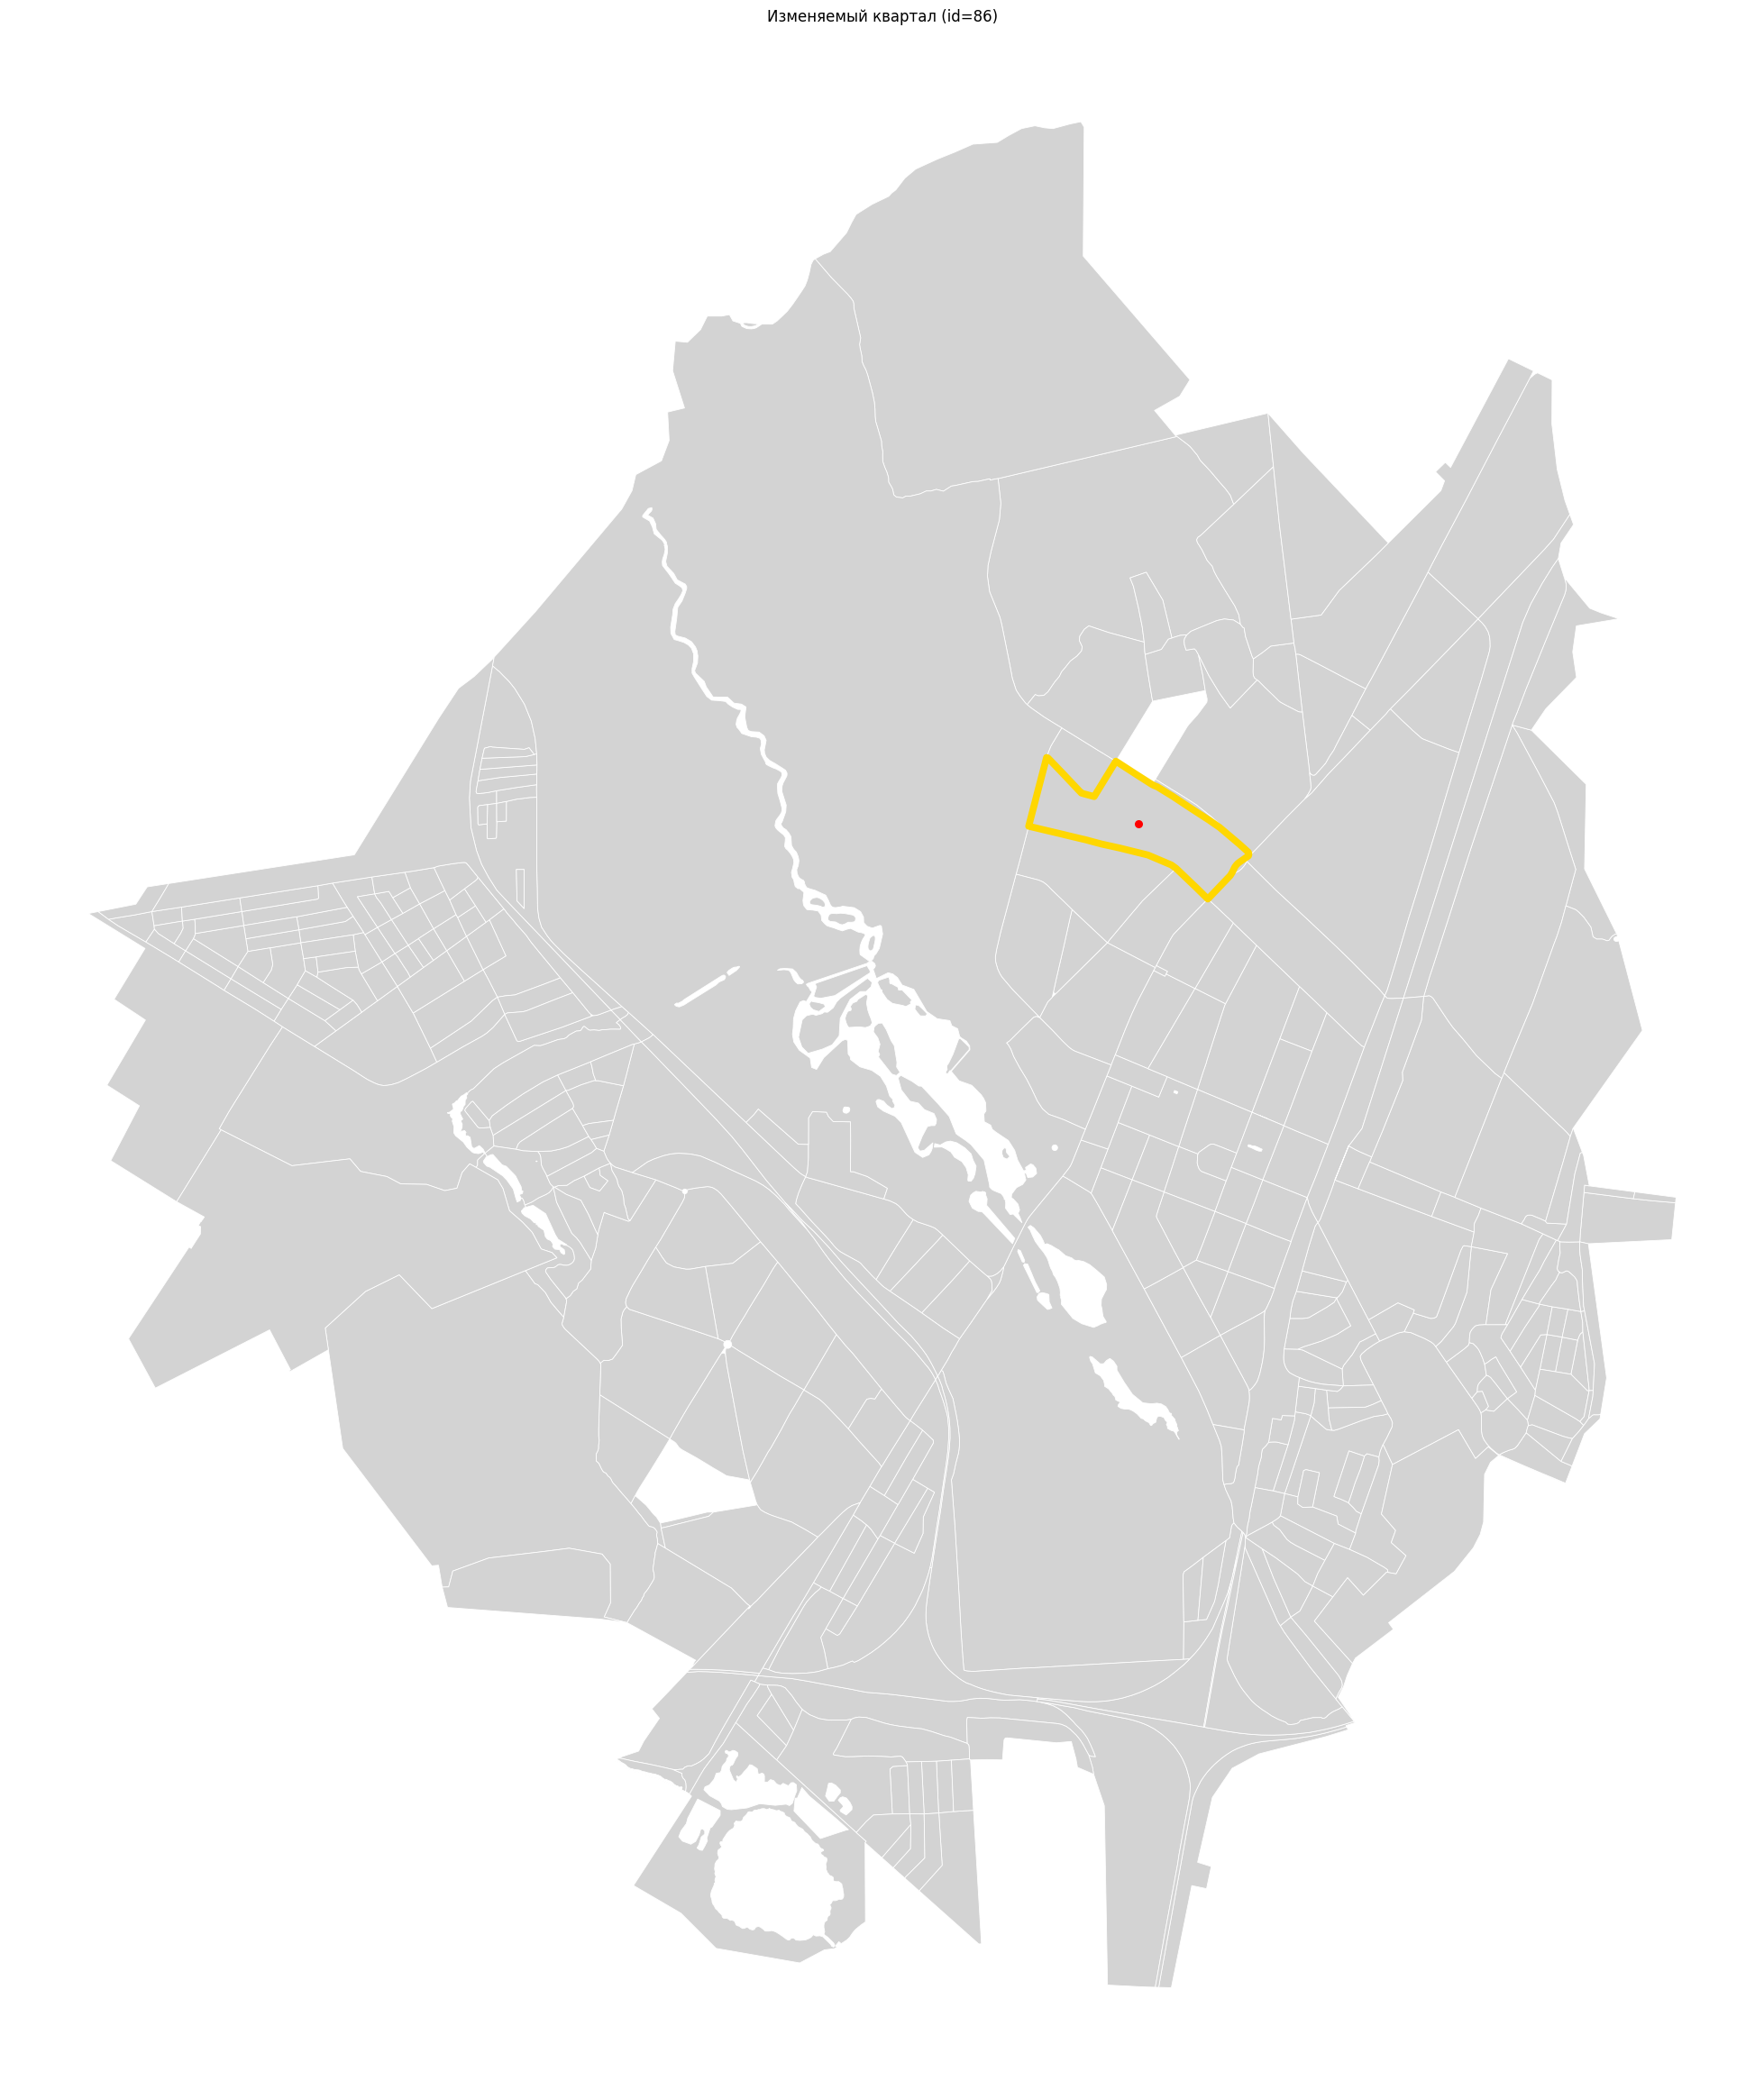

In [17]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [19]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Проверка стабильности модели по Гатчине

In [22]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3", base_url="http://localhost:11434")

In [12]:
from urbanomy.methods.agent import init_llm

llm = init_llm("deepseek/deepseek-v4-flash")

In [13]:
llm.invoke('Привет')

AIMessage(content='Привет! Рад(а) тебя видеть! 👋\n\nЯ — DeepSeek, твой виртуальный помощник. Чем могу помочь сегодня? Может, хочешь что-то спросить, обсудить или решить какую-то задачу?\n\nРассказывай, я весь во внимании! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 267, 'prompt_tokens': 6, 'total_tokens': 273, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 190, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '7a392749-e26d-4bb6-8685-1b272042f54f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f183d-64c9-7aa1-badb-0134730c55ab-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 267, 'total_tokens': 273, 'input_token_details': {

In [80]:
baseline = SingleAgentBaseline(llm=llm)

In [14]:
import json
from pathlib import Path
import pandas as pd


In [15]:
prompts = ['Evaluate the presented scenario based on the criterion of social inclusiveness and low displacement risk.Determine whether the scenario preserves the social and functional diversity of the area, access to everyday services, and opportunities for vulnerable user groups.Assign a score from 0 to 1. Give only score for answer',
           'Evaluate the presented scenario based on the criterion of strategic relevance for the long-term development of the city and district.Consider compactness, functional mix, the balance of housing, jobs, and services, and the area`s ability to adapt to future changes. Assign a score from 0 to 1. Give only score for answer',
           'Evaluate the presented scenario based on its ability to create conditions for active urban life.Consider functional mix, the potential for active ground floors, pedestrian accessibility, public spaces, and diverse everyday use scenarios throughout the day and evening.Assign a score from 0 to 1. Give only score for answer',
           'Evaluate the presented scenario based on the criterion of aligning the interests of various land users and minimizing conflict risk.Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.Assign a score from 0 to 1. Give only score for answer',
           'Evaluate the presented scenario based on the criterion of environmental and infrastructure sustainability.Consider building density, transport and infrastructure load, resource efficiency, environmental consequences, and the possibility of phased adaptation of the area.Assign a score from 0 to 1. Give only score for answer']

In [21]:
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import pandas as pd


notebook_dir = Path('examples') if Path('examples/paper.ipynb').exists() else Path('.')
out_path = notebook_dir / 'goals_evaluation_deepseek2.csv'


tasks = []

ctx_keys = numeric_feats + cat_features

for index, row in blocks_clean.iterrows():

    block_id = int(row['id']) if 'id' in row.index else int(index)

    ctx = {}

    for k in ctx_keys:
        if k in row.index and pd.notnull(row[k]):
            value = row[k]

            if isinstance(value, (int, float)):
                ctx[k] = float(value)
            else:
                ctx[k] = str(value)

    for prompt in prompts:
        task = f"{prompt}\n\nКонтекст района (id={block_id}): {ctx}"

        tasks.append(
            {
                "id": block_id,
                "prompt": prompt,
                "task": task
            }
        )


def call_llm(item):
    try:
        output = llm.invoke(item["task"]).content
    except Exception as e:
        output = f"ERROR: {e}"

    return {
        "id": item["id"],
        "prompt": item["prompt"],
        "output": output
    }


results = []

with ThreadPoolExecutor(max_workers=20) as executor:

    futures = [
        executor.submit(call_llm, task)
        for task in tasks
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Оценка кварталов"
    ):
        results.append(future.result())


eval_df = pd.DataFrame(results)

eval_df.to_csv(
    out_path,
    index=False,
    encoding='utf-8'
)

eval_df.head()

Оценка кварталов:   0%|          | 0/1665 [00:00<?, ?it/s]

,id,prompt,output
0,0,Evaluate the presented scenario based on the c...,0.2
1,1,Evaluate the presented scenario based on the c...,0.2
2,3,Evaluate the presented scenario based on the c...,0.2
3,4,Evaluate the presented scenario based on its a...,0.1
4,0,Evaluate the presented scenario based on the c...,0.9


In [22]:
eval_df = pd.DataFrame(results)
eval_df['output']

0        0.2
1        0.2
2        0.2
3        0.1
4        0.9
        ... 
1660     0.7
1661     0.5
1662     0.7
1663     0.5
1664    0.45
Name: output, Length: 1665, dtype: object

In [25]:
blocks_clean = blocks_clean[~blocks_clean['id'].isin(eval_df['id'])]
blocks_clean

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,id,geometry,site_area,land_value,land_value_per_100m2
196,0.171365,0.595096,0.195065,0.000000,0.038475,0.000000,0.0,LandUse.BUSINESS,0.595096,13416.214564,...,0.063728,0.374425,1.530752,individual residential,7.875437,196,"POLYGON ((30.11089 59.56088, 30.11177 59.56049...",54208.010169,1.496965e+08,276152.075474
197,0.519775,0.000000,0.035611,0.000000,0.207394,0.236550,0.0,LandUse.RESIDENTIAL,0.519775,9732.302559,...,0.013193,0.703932,1.206160,individual residential,10.029413,197,"POLYGON ((30.07397 59.5843, 30.07427 59.58415,...",189739.821988,4.703644e+08,247899.697452
198,0.831643,0.000000,0.024114,0.000000,0.000000,0.144244,0.0,LandUse.RESIDENTIAL,0.831643,914.419942,...,0.024844,0.686519,1.141117,individual residential,9.475581,198,"POLYGON ((30.07691 59.5798, 30.0769 59.57962, ...",9466.152915,4.063183e+07,429232.738252
199,0.897589,0.000000,0.016809,0.000000,0.000000,0.085602,0.0,LandUse.RESIDENTIAL,0.897589,1035.514329,...,0.018750,0.749489,1.168759,individual residential,10.083723,199,"POLYGON ((30.07692 59.58023, 30.07691 59.5798,...",14203.477825,6.345154e+07,446732.395345
200,0.884211,0.000000,0.021975,0.000000,0.000000,0.093814,0.0,LandUse.RESIDENTIAL,0.884211,710.723209,...,0.016441,0.786010,1.381235,individual residential,10.568897,200,"POLYGON ((30.07694 59.58058, 30.07692 59.58023...",11117.681429,4.998752e+07,449621.800373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,0.085212,0.005620,0.000000,0.042102,0.000000,0.877347,0.0,LandUse.SPECIAL,0.877347,2246.815967,...,0.002989,0.197735,1.381096,individual residential,12.661504,346,"POLYGON ((30.13472 59.59243, 30.13519 59.59012...",193241.346964,2.518114e+08,130309.282728
347,0.603114,0.000000,0.000000,0.000000,0.000000,0.392772,0.0,LandUse.RESIDENTIAL,0.603114,0.000000,...,0.000000,0.000000,0.000000,0,10.657258,347,"POLYGON ((30.13429 59.59456, 30.13472 59.59243...",228947.276393,4.382302e+08,191410.988056
348,0.921247,0.007951,0.070064,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.921247,0.000000,...,0.000000,0.000000,0.000000,0,10.546195,348,"POLYGON ((30.06949 59.54791, 30.06991 59.54711...",183321.519167,4.163139e+08,227094.962053
349,0.604336,0.000000,0.393593,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.604336,0.000000,...,0.000000,0.000000,0.000000,0,9.879099,349,"POLYGON ((30.084 59.5465, 30.08427 59.54673, 3...",146432.141805,2.705361e+08,184751.885785


In [ ]:
#eval_df.to_csv('goals_evaluation_deepseek.csv')

In [ ]:
eval_df = pd.read_csv('goals_evaluation_deepseek.csv')

In [23]:
eval_df['id']

0         0
1         1
2         3
3         4
4         0
       ... 
1660    349
1661    348
1662    347
1663    349
1664    350
Name: id, Length: 1665, dtype: int64

In [24]:
eval_df['output_clean'] = pd.to_numeric(

    eval_df['output'],

    errors='coerce'

)

In [25]:
blocks_evaluated = blocks_clean.merge(
    eval_df,
    left_on='id',
    right_on='id',
    how='left'
)
blocks_evaluated.shape

(1665, 28)

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import Pool


def plot_catboost_shap_radar(
        model,
        X,
        cat_features=None,
        top_n=10,
        feature_order=None
):

    """
    Radar SHAP importance для CatBoost
    с фиксированным расположением признаков.
    """

    # Pool
    pool = Pool(
        data=X,
        cat_features=cat_features
    )

    # SHAP
    shap_values = model.get_feature_importance(
        data=pool,
        type="ShapValues"
    )

    shap_values = shap_values[:, :-1]


    # importance
    shap_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": np.abs(shap_values).mean(axis=0)
    })


    # если порядок не задан - берем топ признаки первой модели
    if feature_order is None:

        shap_importance = (
            shap_importance
            .sort_values(
                "importance",
                ascending=False
            )
            .head(top_n)
        )

        feature_order = shap_importance["feature"].tolist()


    # оставляем фиксированный порядок
    radar_df = (
        shap_importance
        .set_index("feature")
        .reindex(feature_order)
        .fillna(0)
        .reset_index()
    )


    labels = radar_df["feature"].tolist()
    values = radar_df["importance"].tolist()


    # замыкаем круг
    values += values[:1]


    angles = np.linspace(
        0,
        2*np.pi,
        len(labels),
        endpoint=False
    ).tolist()

    angles += angles[:1]


    # график
    fig, ax = plt.subplots(
        figsize=(8,8),
        subplot_kw={"polar": True}
    )


    ax.plot(
        angles,
        values,
        linewidth=2
    )

    ax.fill(
        angles,
        values,
        alpha=0.25
    )


    ax.set_xticks(
        angles[:-1]
    )

    ax.set_xticklabels(
        labels,
        fontsize=10
    )


    ax.set_title(
        "SHAP importance Radar",
        pad=20
    )


    plt.tight_layout()
    plt.show()


    return radar_df, feature_order

Learning rate set to 0.034413
0:	learn: 0.2214704	total: 58.8ms	remaining: 58.8s
100:	learn: 0.1563280	total: 129ms	remaining: 1.14s
200:	learn: 0.1340876	total: 193ms	remaining: 766ms
300:	learn: 0.1166259	total: 260ms	remaining: 603ms
400:	learn: 0.1001489	total: 330ms	remaining: 493ms
500:	learn: 0.0873885	total: 393ms	remaining: 392ms
600:	learn: 0.0758558	total: 462ms	remaining: 306ms
700:	learn: 0.0670334	total: 528ms	remaining: 225ms
800:	learn: 0.0585361	total: 591ms	remaining: 147ms
900:	learn: 0.0521692	total: 652ms	remaining: 71.6ms
999:	learn: 0.0465165	total: 716ms	remaining: 0us


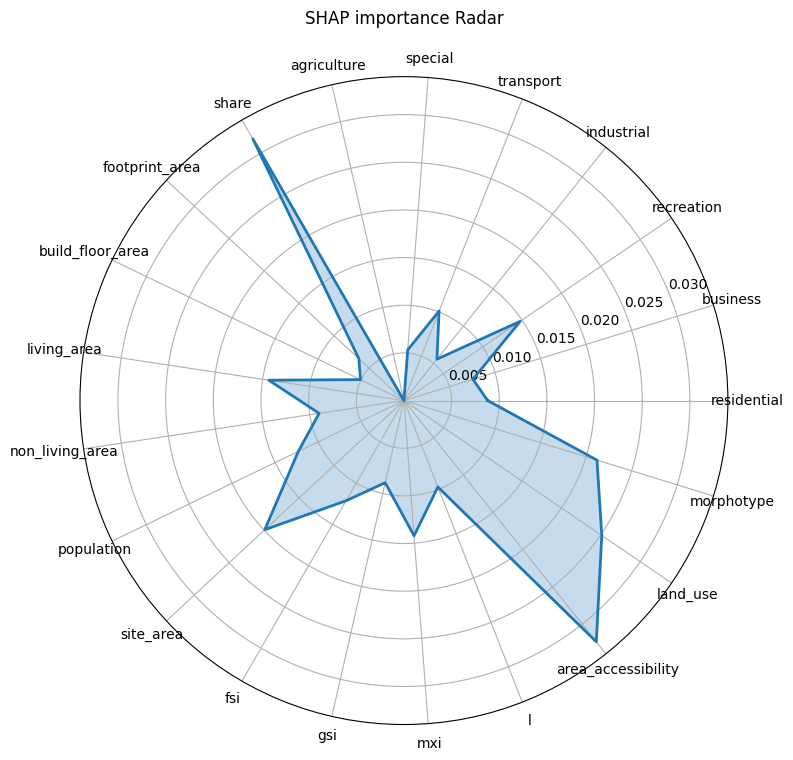

Learning rate set to 0.034413
0:	learn: 0.0970901	total: 1.33ms	remaining: 1.33s
100:	learn: 0.0598448	total: 64.4ms	remaining: 573ms
200:	learn: 0.0490489	total: 120ms	remaining: 479ms
300:	learn: 0.0415959	total: 183ms	remaining: 424ms
400:	learn: 0.0359106	total: 246ms	remaining: 367ms
500:	learn: 0.0314652	total: 311ms	remaining: 309ms
600:	learn: 0.0275017	total: 376ms	remaining: 249ms
700:	learn: 0.0234831	total: 440ms	remaining: 188ms
800:	learn: 0.0204920	total: 506ms	remaining: 126ms
900:	learn: 0.0179456	total: 567ms	remaining: 62.3ms
999:	learn: 0.0159000	total: 630ms	remaining: 0us


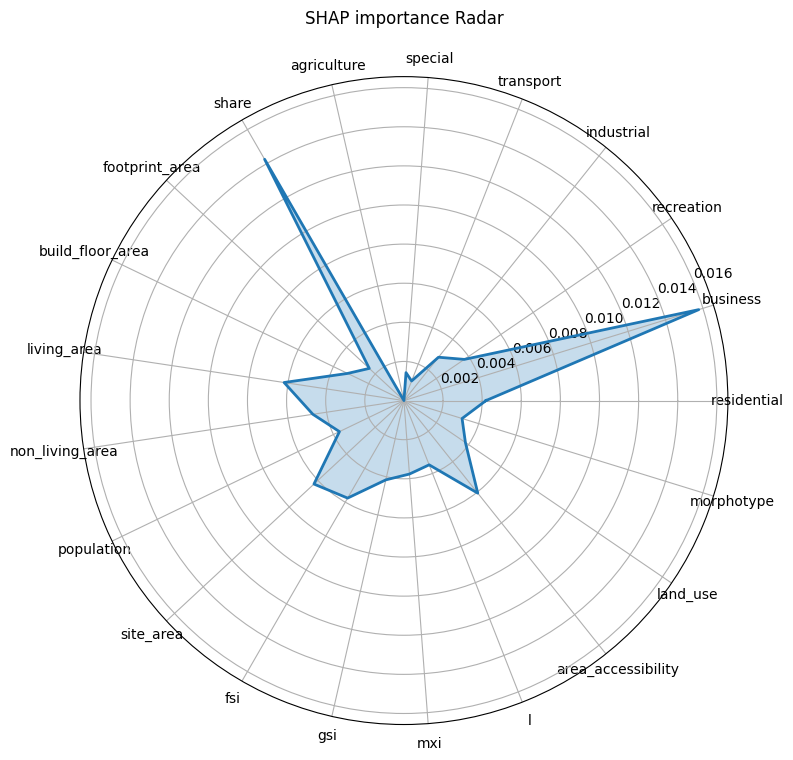

Learning rate set to 0.034413
0:	learn: 0.0951599	total: 2.73ms	remaining: 2.72s
100:	learn: 0.0443108	total: 76.3ms	remaining: 679ms
200:	learn: 0.0353062	total: 146ms	remaining: 580ms
300:	learn: 0.0308869	total: 218ms	remaining: 507ms
400:	learn: 0.0259444	total: 287ms	remaining: 429ms
500:	learn: 0.0224192	total: 357ms	remaining: 355ms
600:	learn: 0.0195136	total: 426ms	remaining: 283ms
700:	learn: 0.0171325	total: 499ms	remaining: 213ms
800:	learn: 0.0149930	total: 568ms	remaining: 141ms
900:	learn: 0.0131976	total: 642ms	remaining: 70.5ms
999:	learn: 0.0118593	total: 707ms	remaining: 0us


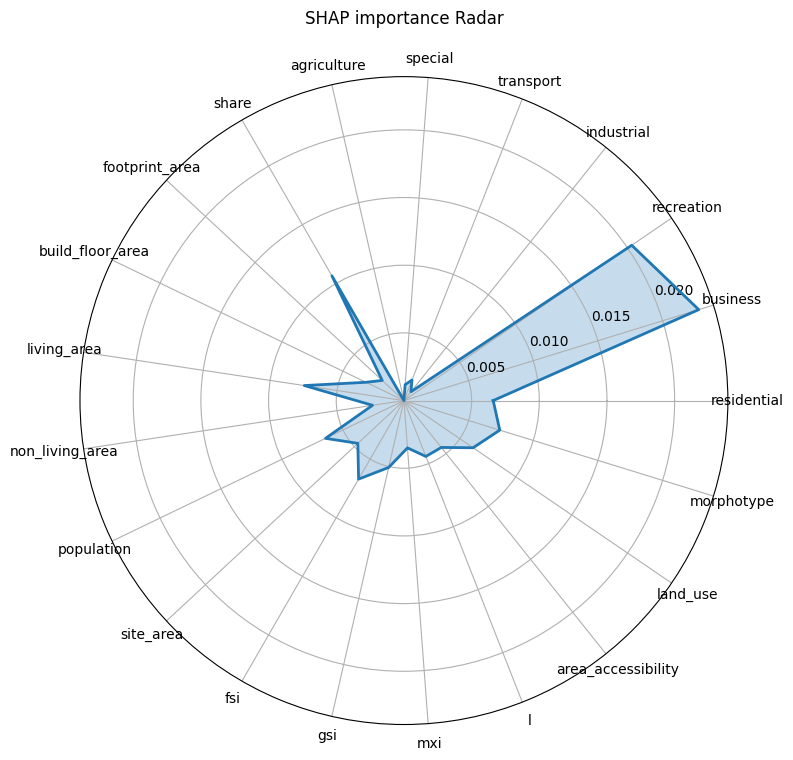

Learning rate set to 0.034413
0:	learn: 0.2091650	total: 628us	remaining: 628ms
100:	learn: 0.1020718	total: 66.6ms	remaining: 593ms
200:	learn: 0.0751536	total: 130ms	remaining: 518ms
300:	learn: 0.0593220	total: 194ms	remaining: 450ms
400:	learn: 0.0495360	total: 262ms	remaining: 391ms
500:	learn: 0.0418844	total: 327ms	remaining: 326ms
600:	learn: 0.0350203	total: 394ms	remaining: 261ms
700:	learn: 0.0298292	total: 458ms	remaining: 195ms
800:	learn: 0.0259722	total: 524ms	remaining: 130ms
900:	learn: 0.0226664	total: 590ms	remaining: 64.8ms
999:	learn: 0.0201464	total: 656ms	remaining: 0us


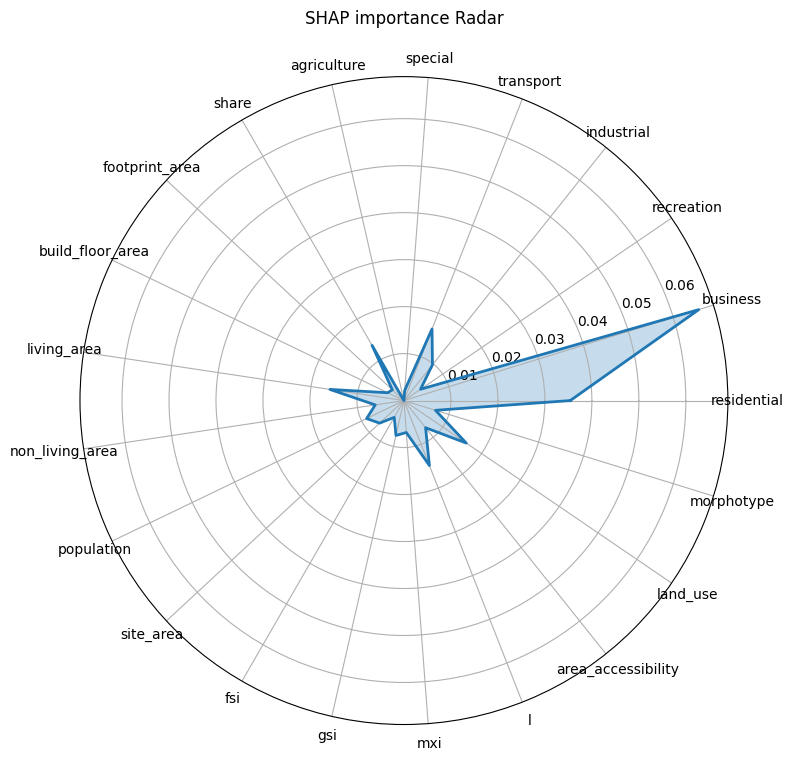

Learning rate set to 0.034413
0:	learn: 0.2350576	total: 1.41ms	remaining: 1.41s
100:	learn: 0.1030124	total: 59.9ms	remaining: 534ms
200:	learn: 0.0848381	total: 119ms	remaining: 473ms
300:	learn: 0.0720381	total: 179ms	remaining: 416ms
400:	learn: 0.0613604	total: 241ms	remaining: 359ms
500:	learn: 0.0537892	total: 301ms	remaining: 300ms
600:	learn: 0.0471565	total: 361ms	remaining: 240ms
700:	learn: 0.0419203	total: 422ms	remaining: 180ms
800:	learn: 0.0375173	total: 480ms	remaining: 119ms
900:	learn: 0.0334913	total: 539ms	remaining: 59.3ms
999:	learn: 0.0303064	total: 596ms	remaining: 0us


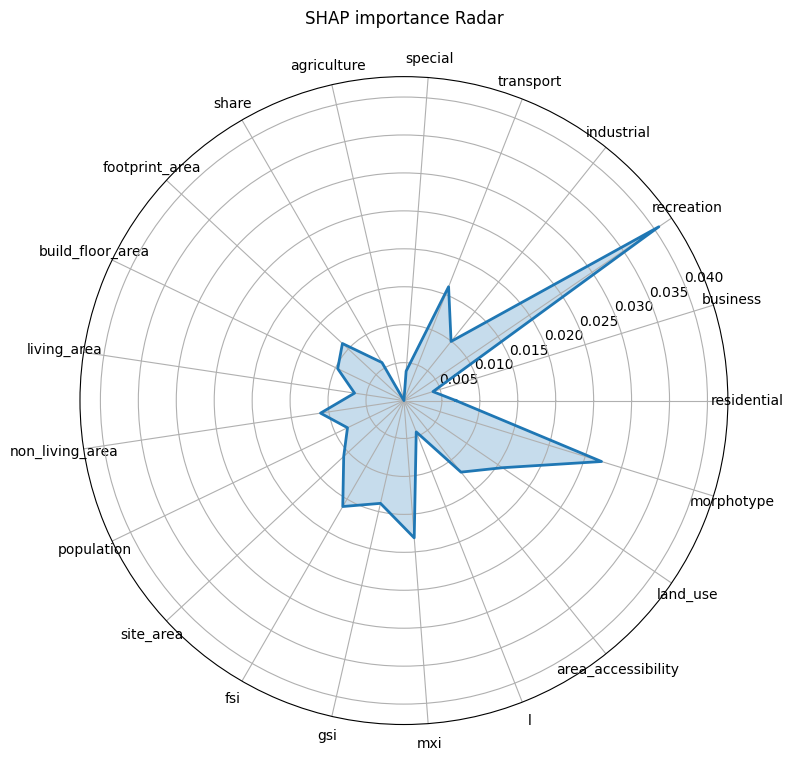

In [27]:
shaps = []
for prompt in prompts:
    df = blocks_evaluated[blocks_evaluated['prompt'] == prompt]
    model = CatBoostRegressor()
    target = df['output_clean'].fillna(df['output_clean'].mean())
    df = df[feature_cols]
    model.fit(df, target,cat_features=cat_features,verbose=100)

    df,_ = plot_catboost_shap_radar(model,df,top_n=20,cat_features=cat_features,feature_order=numeric_feats+cat_features)
    shaps.append(df)

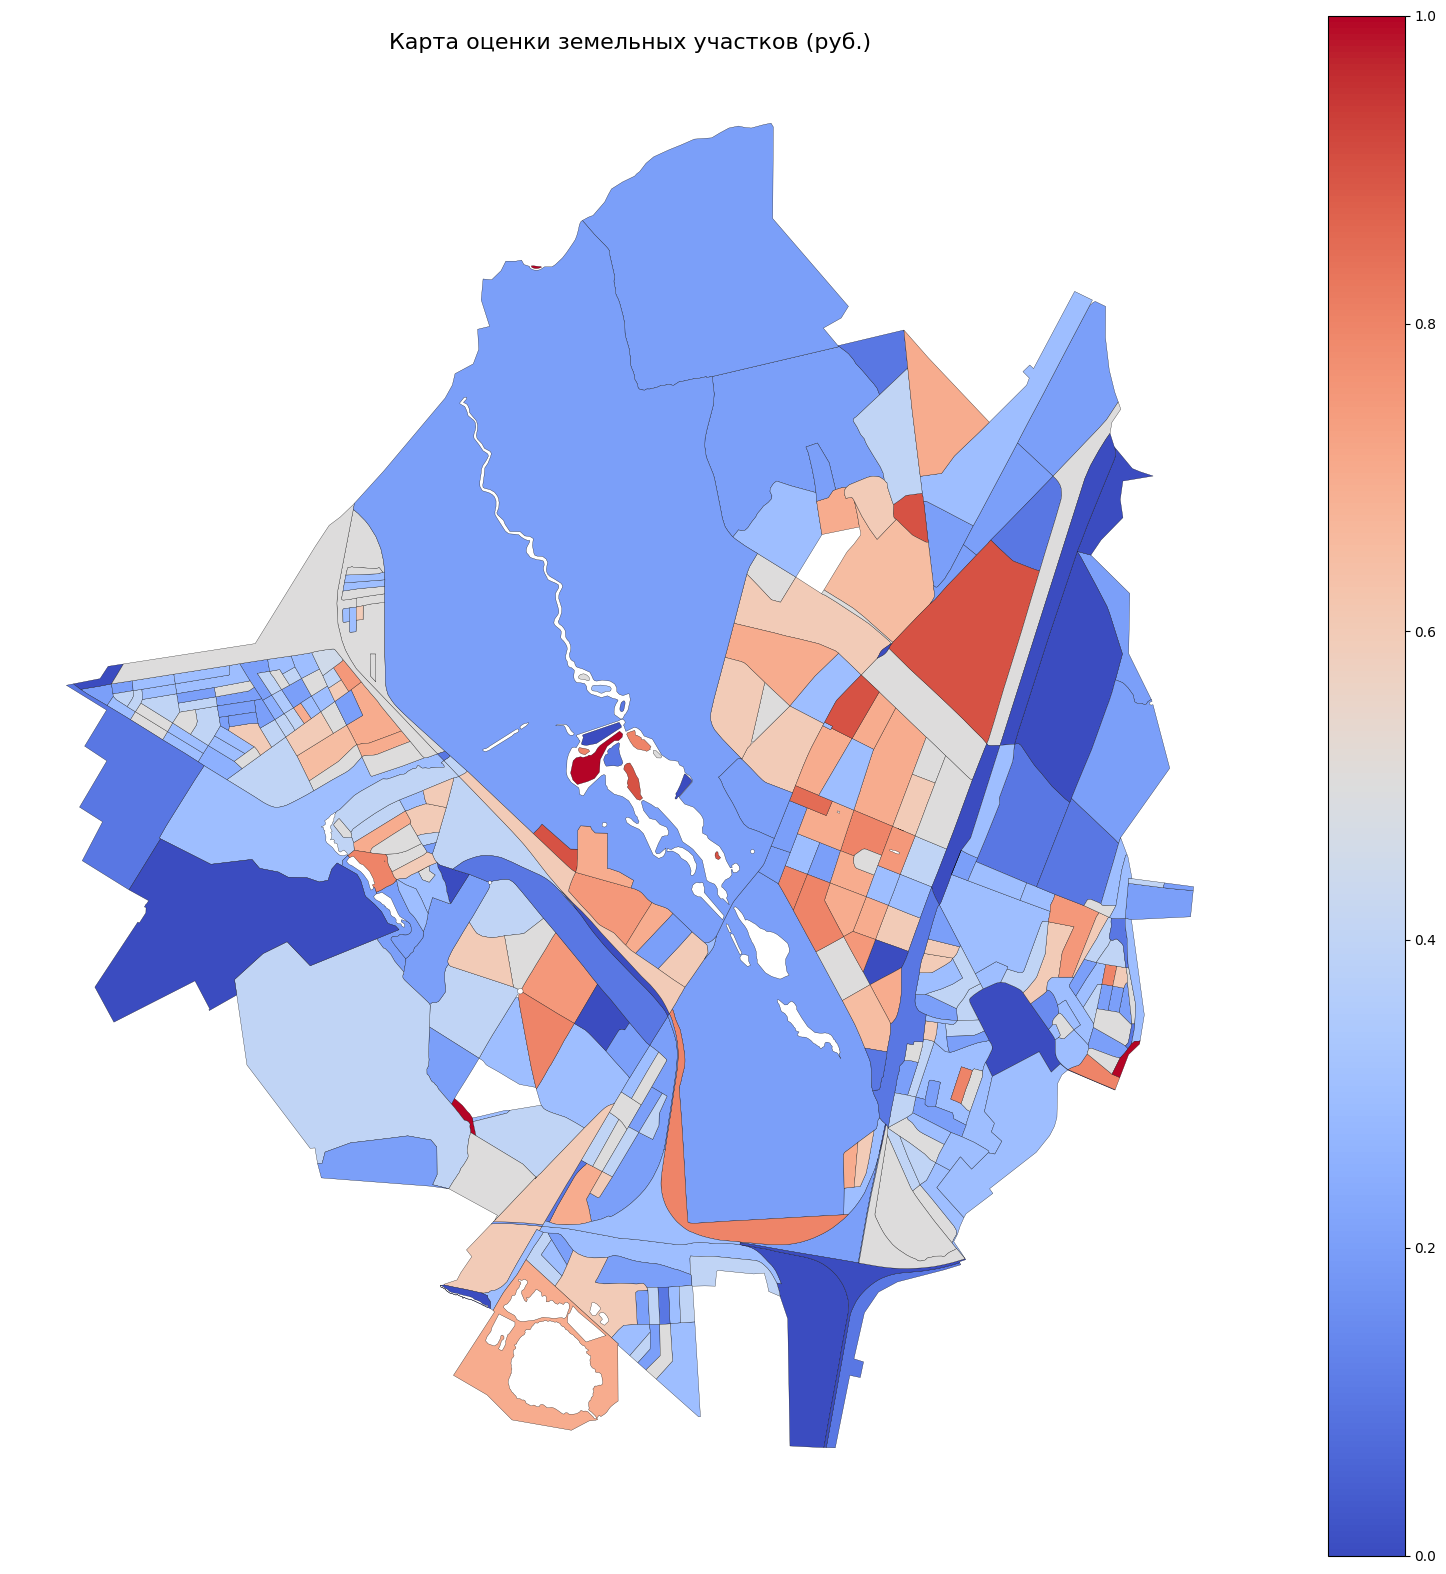

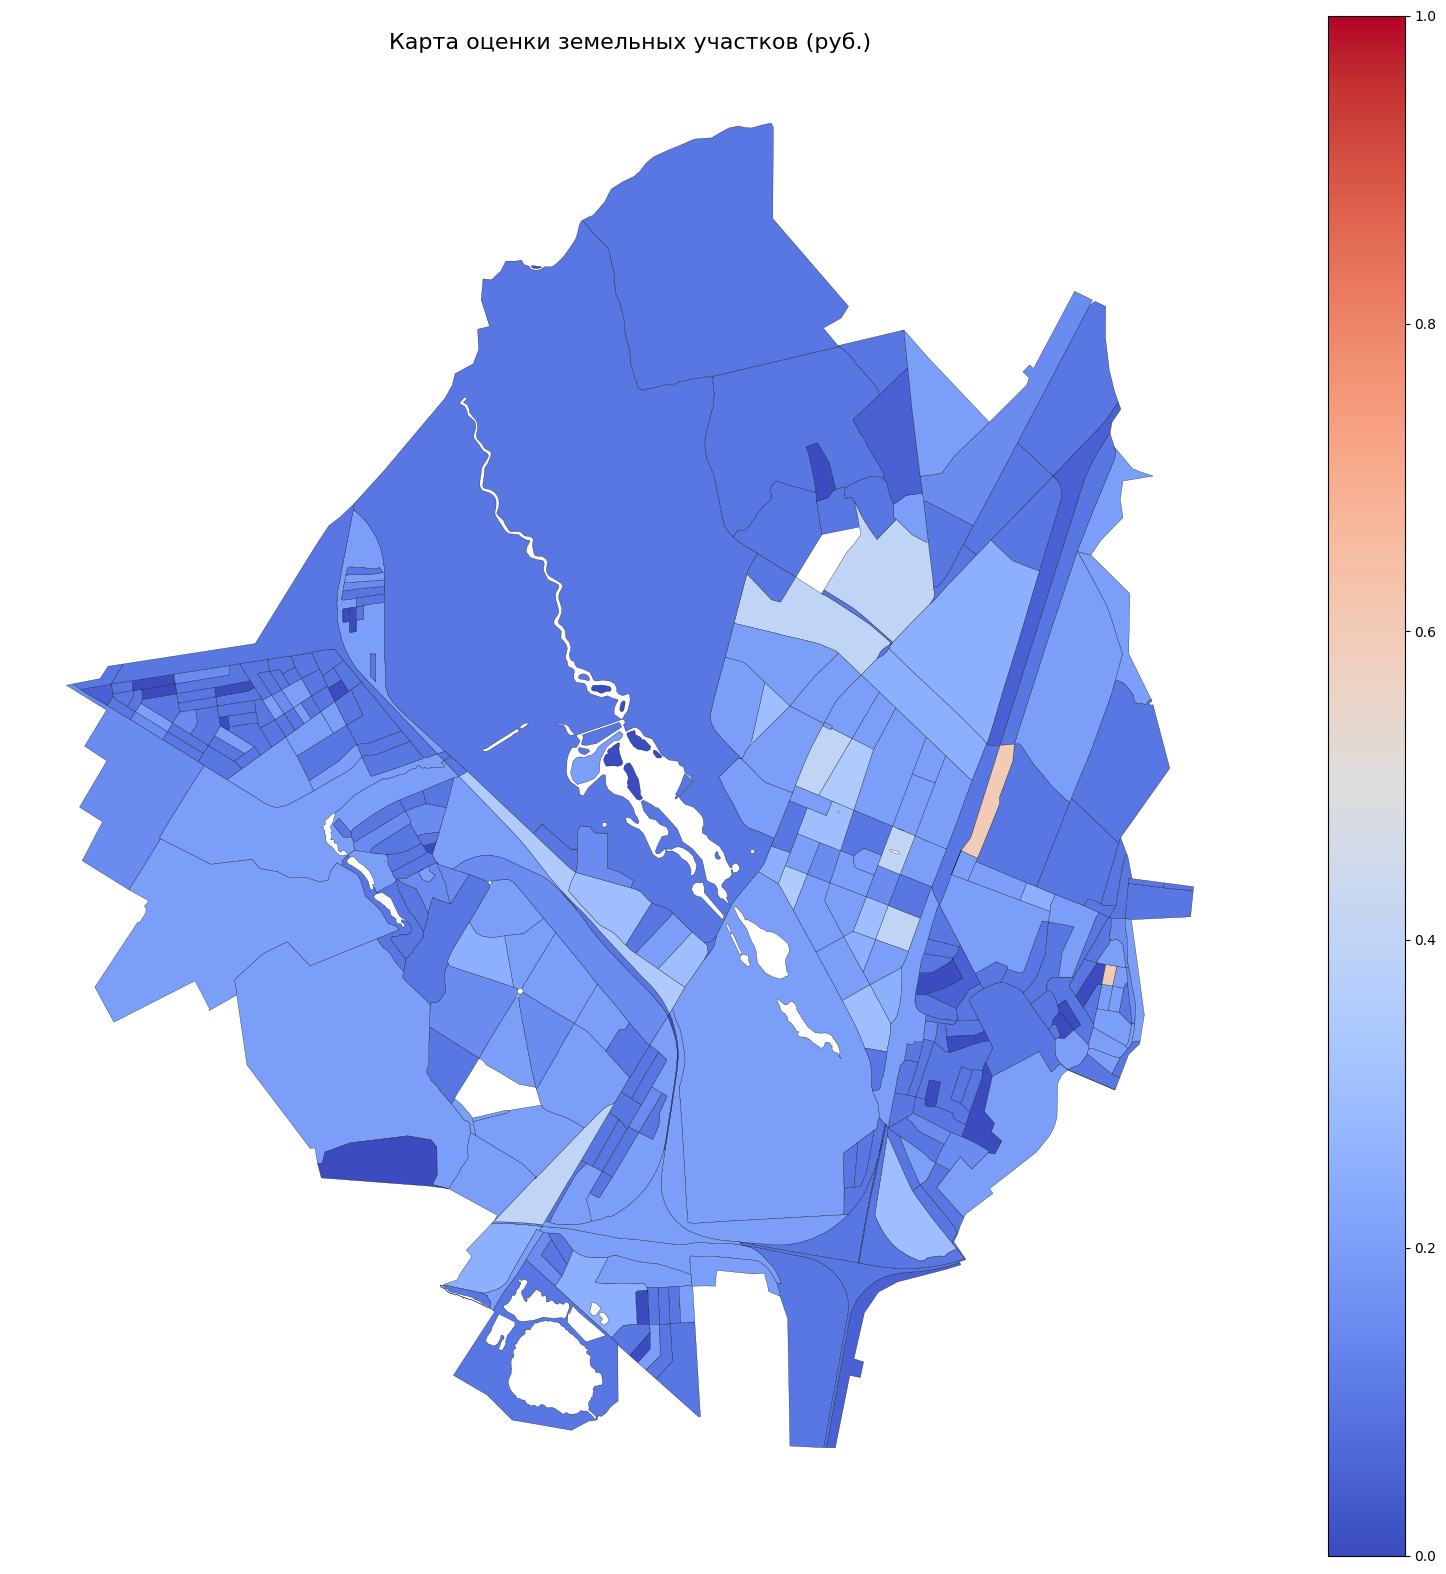

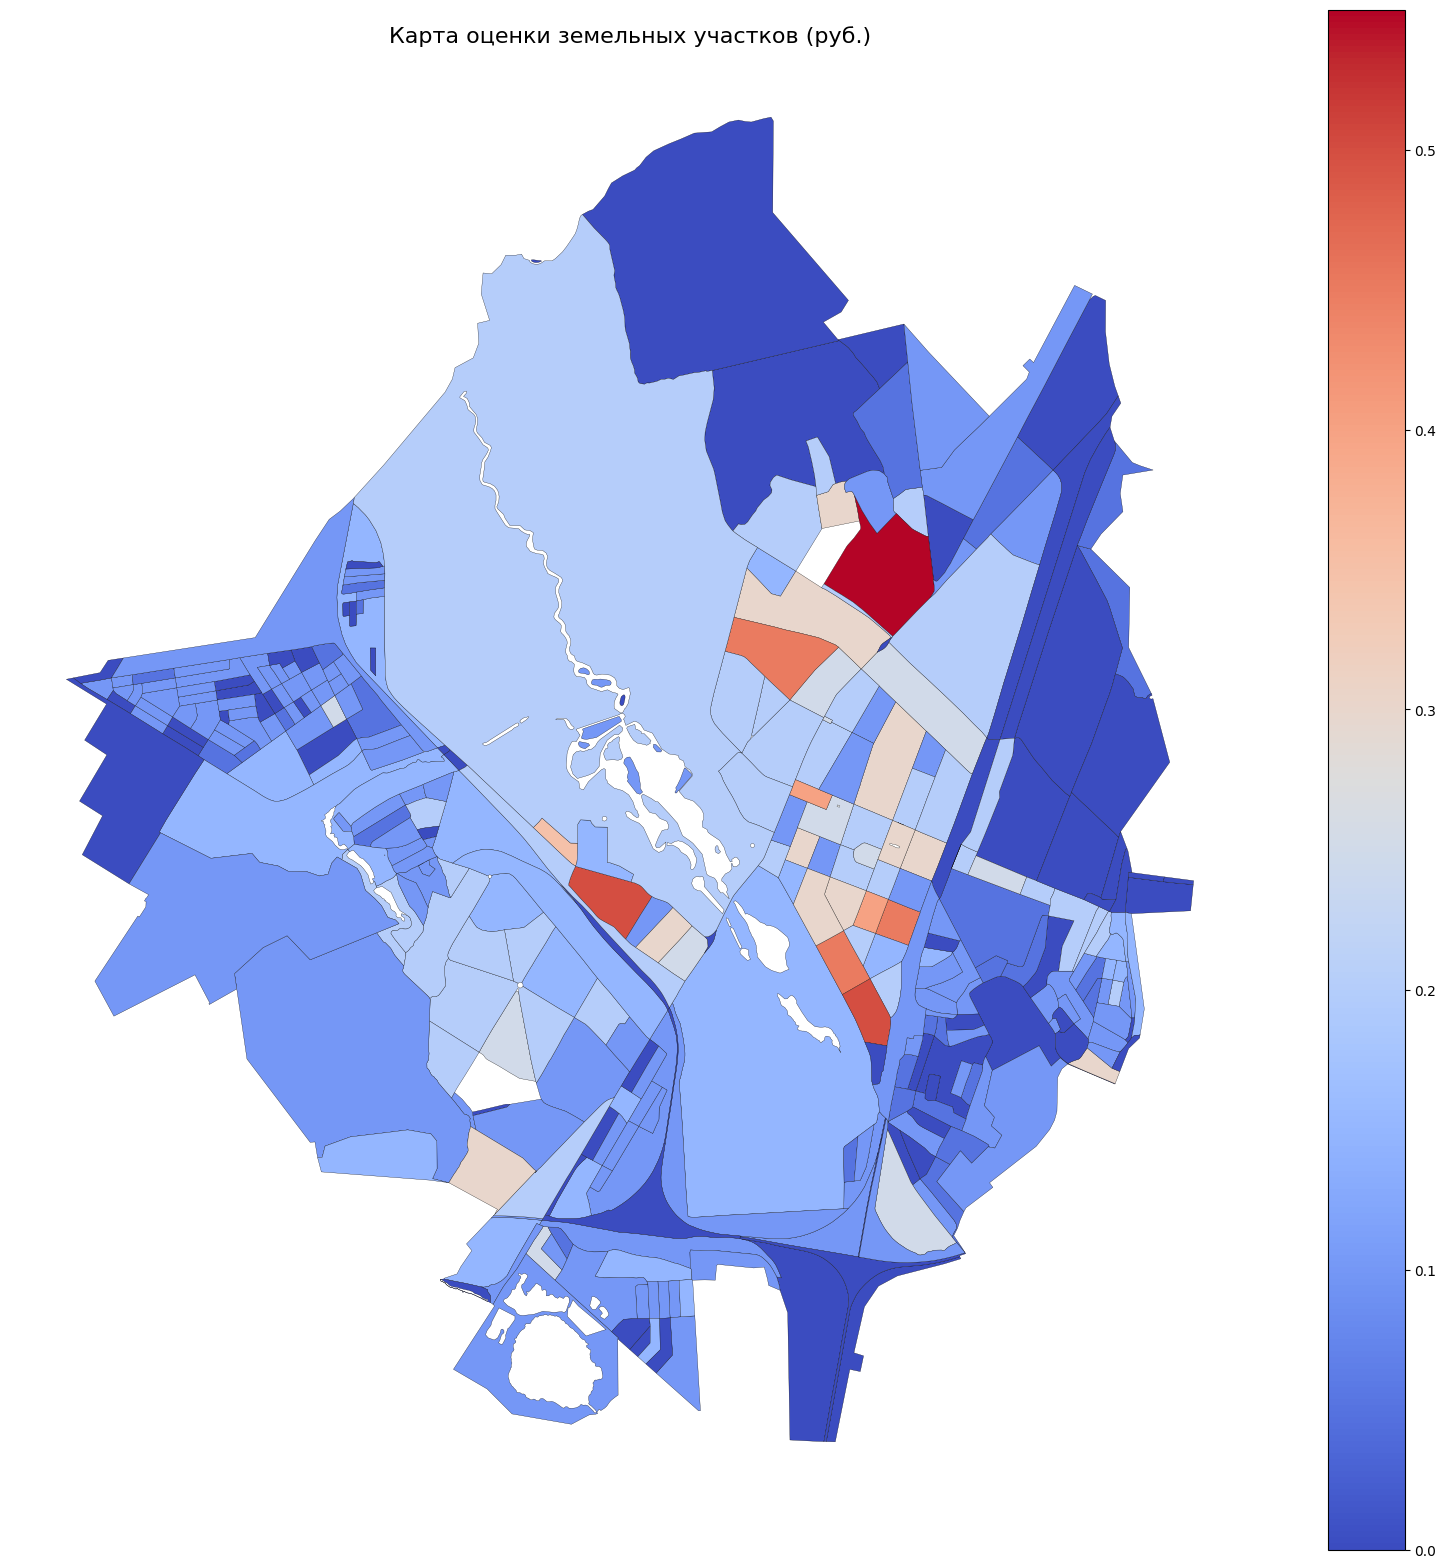

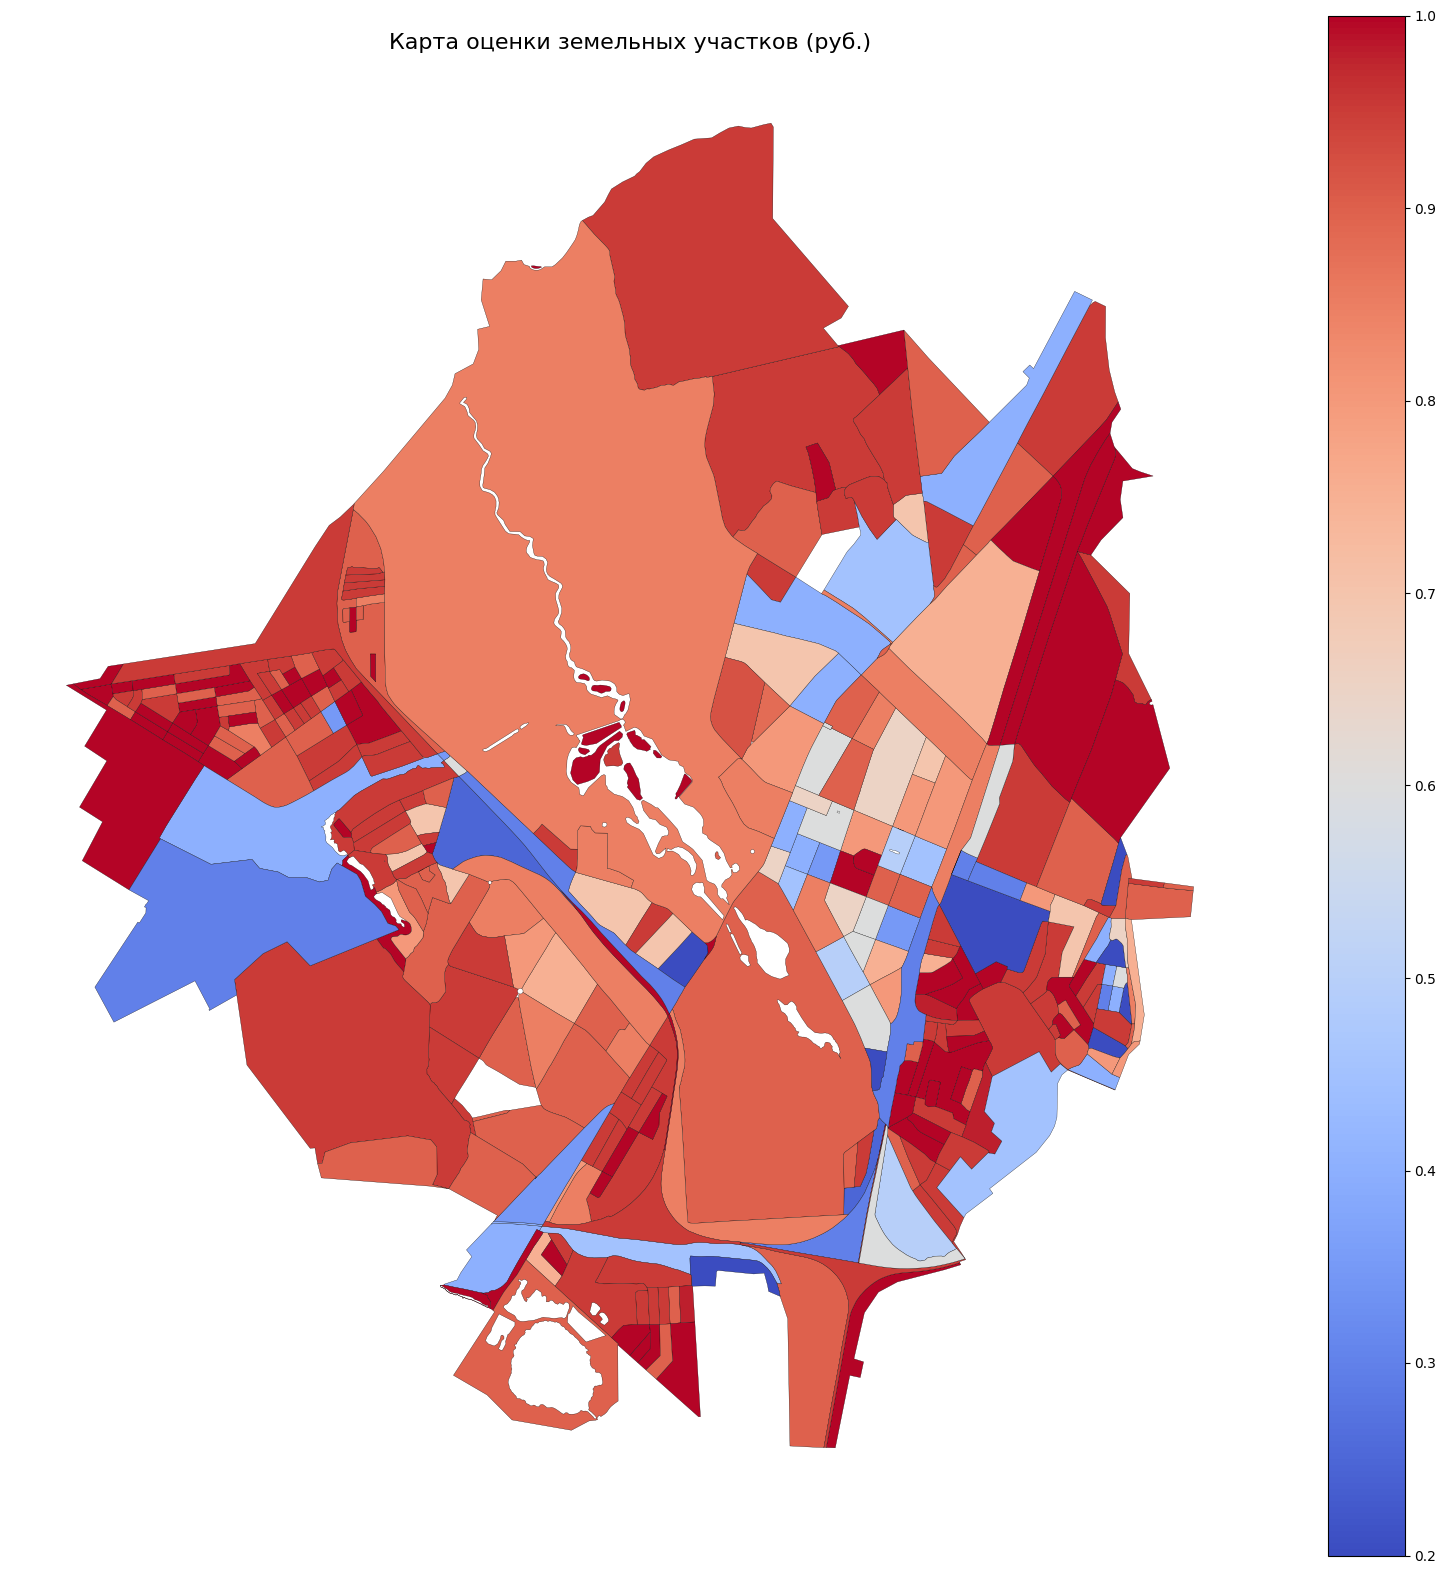

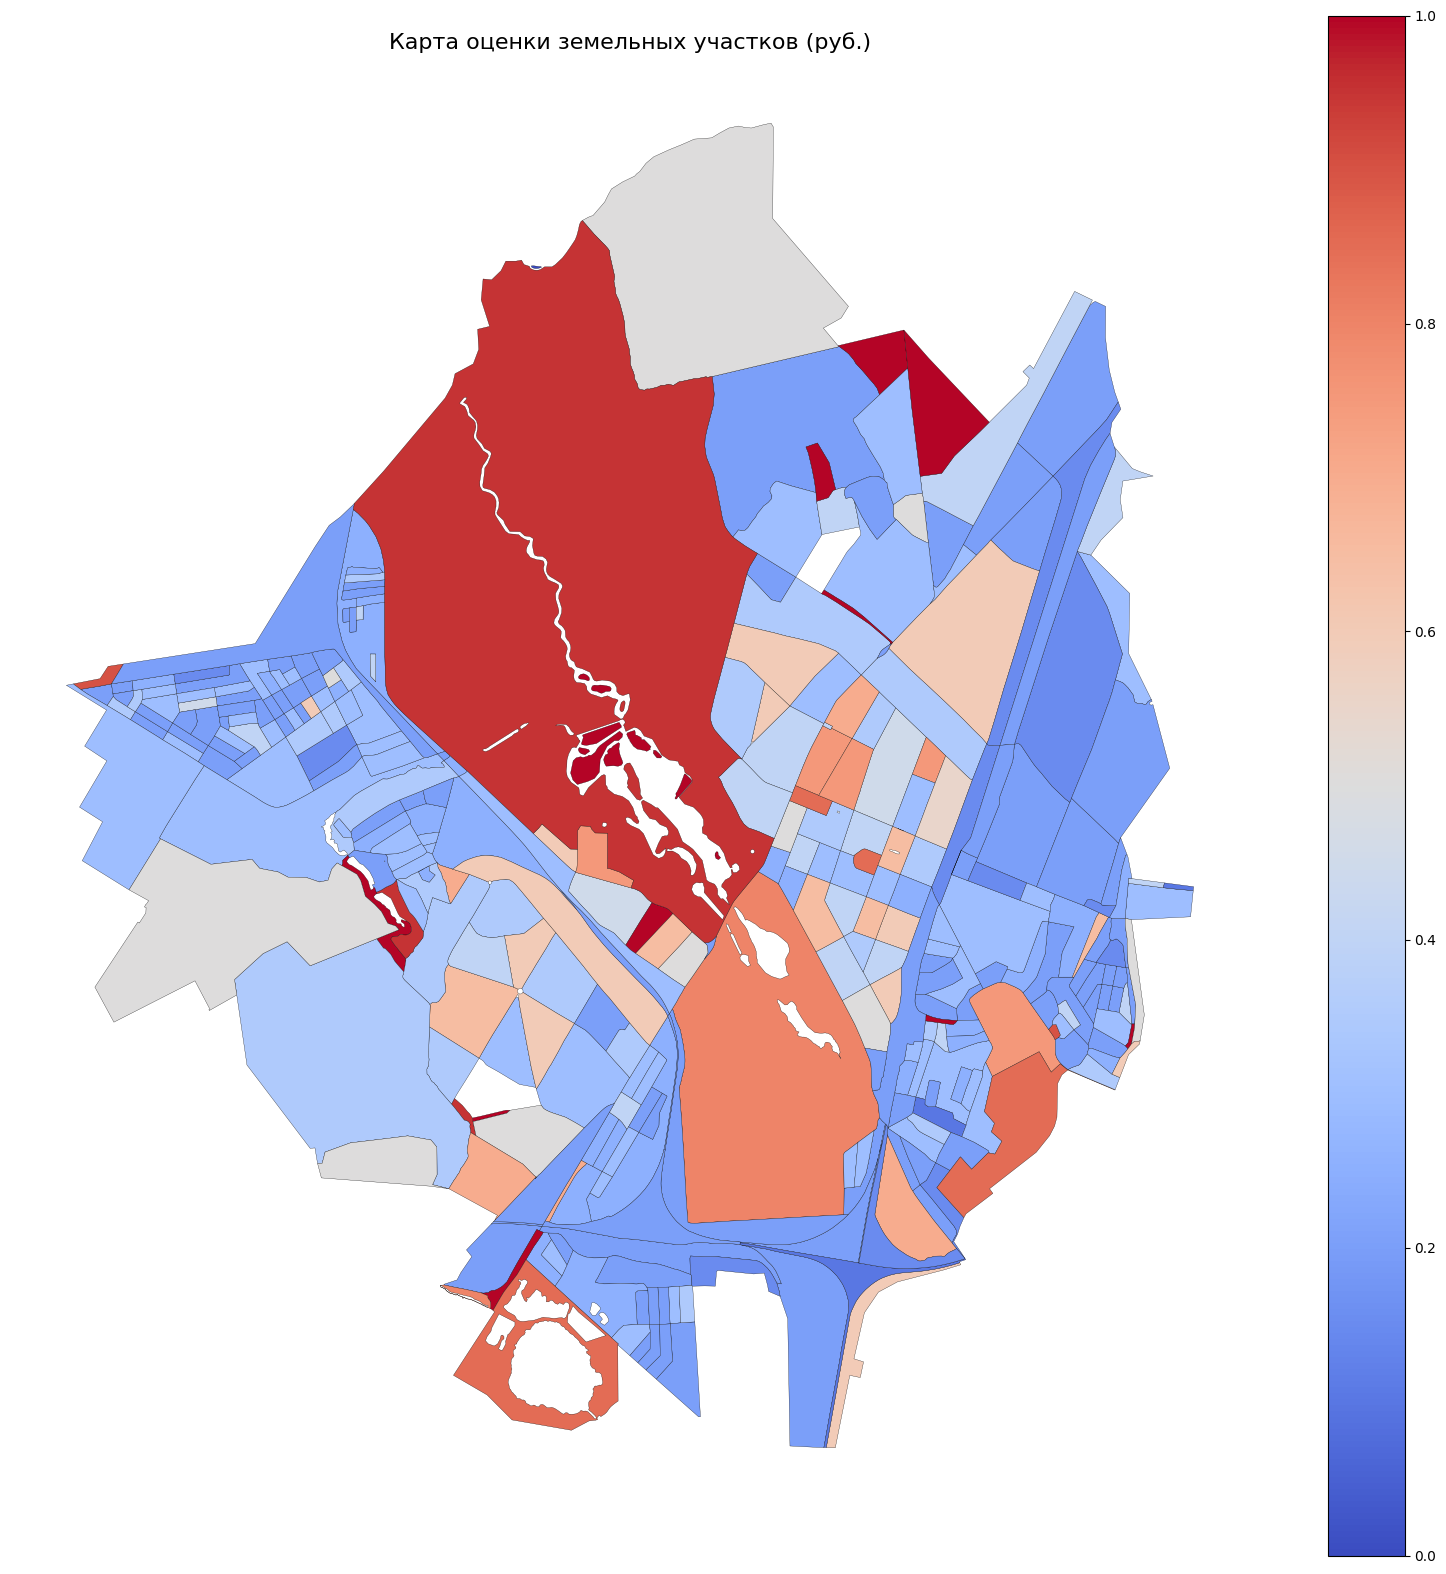

In [28]:
import matplotlib.pyplot as plt
for prompt in prompts:
    blocks_evaluated[blocks_evaluated['prompt']==prompt] \
    .plot(
        column='output_clean',
        legend=True,
        figsize=(20,20),
        cmap='coolwarm',
        edgecolor='black',   # <-- цвет границы
        linewidth=0.2        # <-- толщина границы
    ).set_axis_off()
    plt.title('Карта оценки земельных участков (руб.)', fontsize=16)

    plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def plot_compare_shap_radar(
        radar_results,
        labels,
        names=None
):
    """
    Наложение нескольких SHAP radar-графиков друг на друга.

    Parameters
    ----------
    radar_results : list of pd.DataFrame
        Список результатов из plot_catboost_shap_radar()

    labels : list
        Фиксированный порядок признаков

    names : list
        Названия моделей/экспериментов
    """


    n = len(labels)


    # углы
    angles = np.linspace(
        0,
        2*np.pi,
        n,
        endpoint=False
    ).tolist()

    angles += angles[:1]


    # фигура
    fig, ax = plt.subplots(
        figsize=(9,9),
        subplot_kw={"polar": True}
    )


    # цвета matplotlib
    colors = plt.cm.tab10.colors


    for i, df in enumerate(radar_results):

        # приводим к одинаковому порядку
        values = (
            df
            .set_index("feature")
            .reindex(labels)
            ["importance"]
            .fillna(0)
            .tolist()
        )


        values += values[:1]


        name = (
            names[i]
            if names is not None
            else f"Model {i+1}"
        )


        ax.plot(
            angles,
            values,
            linewidth=2,
            label=name,
            color=colors[i % len(colors)]
        )


        ax.fill(
            angles,
            values,
            alpha=0.15,
            color=colors[i % len(colors)]
        )


    # подписи
    ax.set_xticks(
        angles[:-1]
    )

    ax.set_xticklabels(
        labels,
        fontsize=10
    )


    ax.set_title(
        "Comparison SHAP importance",
        pad=25
    )


    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.25,1.15)
    )


    plt.tight_layout()
    plt.show()

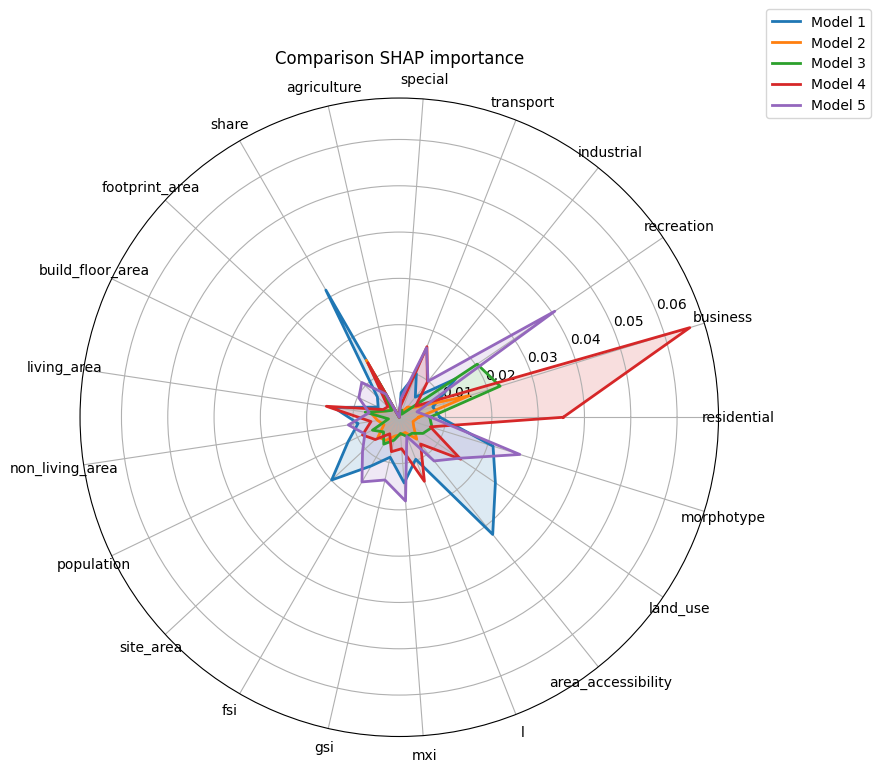

In [30]:
plot_compare_shap_radar(shaps, labels=numeric_feats+cat_features)

In [33]:
from esda.moran import Moran

import libpysal

In [34]:
for prompt in prompts:
    gdf = blocks_evaluated[blocks_evaluated['prompt']==prompt]
    w = libpysal.weights.KNN.from_dataframe(gdf, k=5)

    w.transform = 'r'

    moran = Moran(gdf['output_clean'], w)

    print(moran.I)

0.04926803636931594
0.186873920552677
0.3202892546057196
0.27107128773950495
0.36144606780780225


# Оптимизация района

## NSGA 2

In [20]:
site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
    run_nsga2_with_strategic_alignment,
)
from pathlib import Path
import pandas as pd

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
optimization_log_path = notebook_dir / "optimization_log.jsonl"
pareto_front_path = notebook_dir / "pareto_front.jsonl"

prompt = """
Evaluate the presented scenario based on the criterion of balancing the interests of various land users.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
Return only valid JSON without markdown, comments, or explanations, using this exact format:
{"score": 0.0}
""".strip()

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    baseline=baseline,
    prompt=prompt,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
    log_optimization=True,
    optimization_log_path=optimization_log_path,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)
optimization_log_df = pd.DataFrame(problem.optimization_log)

pareto_df.to_json(pareto_front_path, orient="records", lines=True, force_ascii=False)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      3 |             - |             -
     2 |       40 |      4 |  0.5000000000 |         ideal
     3 |       60 |      6 |  0.0344766839 |             f
     4 |       80 |      9 |  0.1703305043 |         ideal
     5 |      100 |      8 |  0.0233942571 |         ideal
     6 |      120 |     12 |  0.0165743766 |         ideal
     7 |      140 |     13 |  0.1521537326 |         ideal
     8 |      160 |     17 |  0.1372493790 |         ideal
     9 |      180 |     17 |  0.0198906570 |         ideal
    10 |      200 |     19 |  0.0029267798 |         ideal
    11 |      220 |     18 |  0.0909090909 |         ideal
    12 |      240 |     19 |  0.1196908404 |         ideal
    13 |      260 |     20 |  0.0833333333 |         ideal
    14 |      280 |     20 |  0.0184568693 |             f
    15 |      300 |     20 |  0.0718249438 |         ideal
    16 |      320 |     20 |  0.0242484085 |         ide

In [26]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,llm score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RECREATION,scenario_0 | RECREATION; land_use=RECREATION; ...,RECREATION,6.365899e+10,7.074730e+08,4.529726e+09,"{'footprint_area': 25378.02934831227, 'l': 9.9...",0.80,
1,scenario_1,scenario_1 | BUSINESS,scenario_1 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.309090e+10,1.393819e+08,6.605294e+09,"{'footprint_area': 25107.42816019796, 'l': 9.9...",0.25,
2,scenario_2,scenario_2 | BUSINESS,scenario_2 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.324475e+10,2.932260e+08,6.560384e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.20,
3,scenario_3,scenario_3 | BUSINESS,scenario_3 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.152272e+10,-1.428804e+09,6.577734e+09,"{'footprint_area': 25382.398222395932, 'l': 9....",0.30,
4,scenario_4,scenario_4 | RECREATION,scenario_4 | RECREATION; land_use=RECREATION; ...,RECREATION,6.380302e+10,8.515026e+08,2.873385e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.45,
5,scenario_5,scenario_5 | BUSINESS,scenario_5 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.246027e+10,-4.912495e+08,4.788286e+09,"{'footprint_area': 25170.82169952541, 'l': 9.9...",0.75,
6,scenario_6,scenario_6 | RECREATION,scenario_6 | RECREATION; land_use=RECREATION; ...,RECREATION,6.377729e+10,8.257695e+08,3.043913e+09,"{'footprint_area': 25378.932439220538, 'l': 9....",0.70,
7,scenario_7,scenario_7 | RECREATION,scenario_7 | RECREATION; land_use=RECREATION; ...,RECREATION,6.374831e+10,7.967879e+08,4.477773e+09,"{'footprint_area': 26066.144054081913, 'l': 9....",0.70,
8,scenario_8,scenario_8 | INDUSTRIAL,scenario_8 | INDUSTRIAL; land_use=INDUSTRIAL; ...,INDUSTRIAL,6.295636e+10,4.837149e+06,5.219043e+09,"{'footprint_area': 25350.799635637144, 'l': 9....",0.65,
9,scenario_9,scenario_9 | BUSINESS,scenario_9 | BUSINESS; land_use=BUSINESS; прир...,BUSINESS,6.271597e+10,-2.355464e+08,6.063743e+09,"{'footprint_area': 25380.87049152216, 'l': 9.8...",0.35,


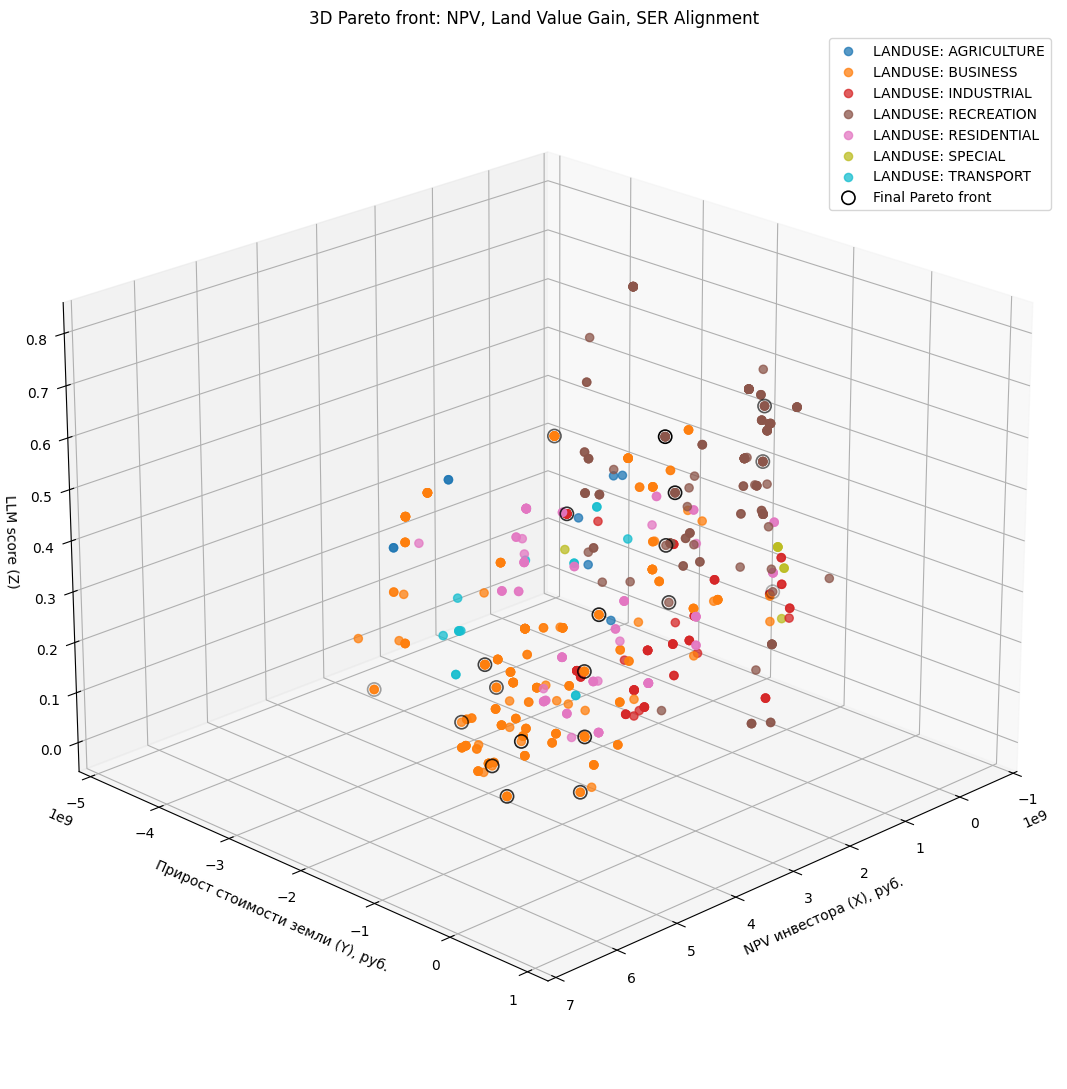

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("LLM score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


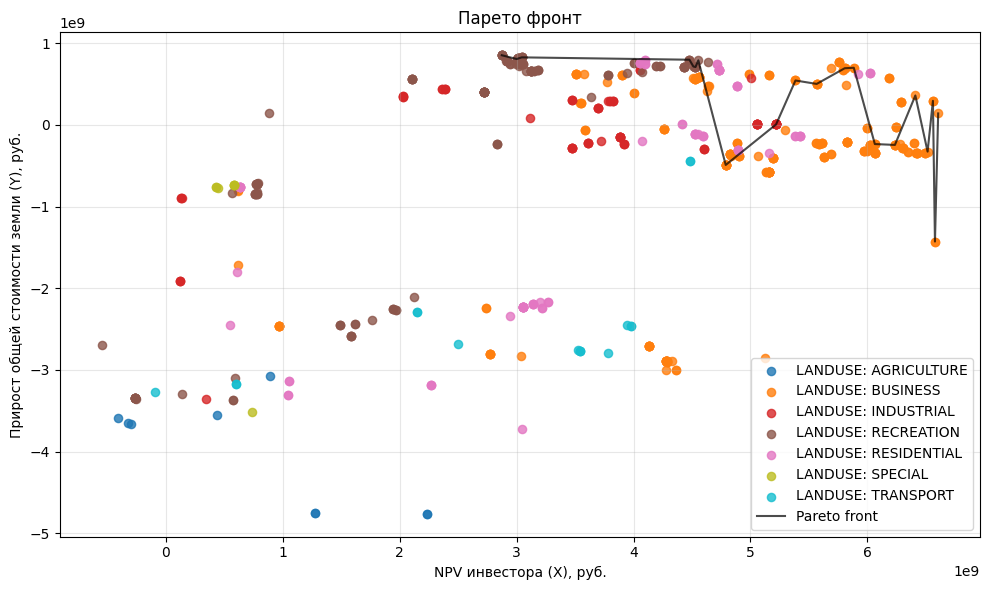

In [24]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

## NSGA II (без LLM)

In [ ]:
from pathlib import Path

import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

from urbanomy.methods.land_value_modeling import DistrictProblem, build_pareto_front_dataframe

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")

problem_no_llm = DistrictProblem(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    log_optimization=True,
)

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res_no_llm = minimize(
    problem_no_llm,
    algorithm,
    ('n_gen', 30),
    seed=42,
    verbose=True,
    save_history=True,
)

no_llm_log_df = pd.DataFrame(problem_no_llm.optimization_log)
no_llm_pareto_df = build_pareto_front_dataframe(
    res=res_no_llm,
    problem=problem_no_llm,
    scenario_prefix="no_llm_pareto",
)

no_llm_log_df.to_json(notebook_dir / "no_llm_optimization_log.jsonl", orient="records", lines=True, force_ascii=False)
no_llm_pareto_df.to_json(notebook_dir / "no_llm_pareto_front.jsonl", orient="records", lines=True, force_ascii=False)


In [ ]:
# idx = np.argmin(res.F[:, 0])   # максимум land_value

# params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
# params_repaired = problem._repair_genome(params_optimal)

# metrics = {
#     "params_repaired": params_repaired,
#     "land_value_after": float(-res.F[idx, 0]),
#     "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
#     "investor_npv": float(-res.F[idx, 1]),
# }
metrics

{'params_repaired': {'footprint_area': 20297.073203890784,
  'l': 4.949905957768471,
  'mxi': 0.1433118074895298,
  'residential': 0.17913975936191223,
  'business': 0.02419225822653892,
  'recreation': 0.2506176739074939,
  'industrial': 0.19552141390717886,
  'transport': 0.20192404099774872,
  'special': 0.032909804252761424,
  'agriculture': 0.11569504934636592,
  'share': 0.17913975936191223,
  'land_use': <LandUse.RECREATION: 'recreation'>,
  'build_floor_area': 100468.60357720178,
  'living_area': 14398.337174597826,
  'non_living_area': 86070.26640260396,
  'population': 719.9168587298913,
  'fsi': 0.3831009655798107,
  'gsi': 0.07739560485559634,
  'morphotype': 'mid-rise non-residential'},
 'land_value_after': 59853915457.40738,
 'land_value_gain': -3097604456.281555,
 'investor_npv': 594080323.95}

In [ ]:
idx = np.argmin(res.F[:, 1])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 19880.925259507625,
  'l': 9.494335591247054,
  'mxi': 0.21382131965569076,
  'residential': 0.26727664956961344,
  'business': 0.13987544747428557,
  'recreation': 0.05824784619830459,
  'industrial': 0.13967156657907198,
  'transport': 0.1481938261292359,
  'special': 0.04617288463916512,
  'agriculture': 0.20056177941032333,
  'share': 0.26727664956961344,
  'land_use': <LandUse.RESIDENTIAL: 'residential'>,
  'build_floor_area': 188756.17627826583,
  'living_area': 40360.09470498099,
  'non_living_area': 148396.08157328484,
  'population': 2018.0047352490496,
  'fsi': 0.7197539411980611,
  'gsi': 0.07580877400853739,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 59941461654.58095,
 'land_value_gain': -3010058259.1079865,
 'investor_npv': 2620941337.21}

Изменение стоимости земли по всем кварталам:
 • Сумма до:    62 951 519 914 ₽
 • Сумма после: 59 941 461 655 ₽
 • Изм.  ₽:     -3 010 058 259 ₽
 • Изм., %:     -4.78%

Изменяемый квартал:
 • До: 590 959 314 ₽ | После: 744 210 221 ₽ | Δ: +153 250 907 ₽ | Δ%: +25.93%


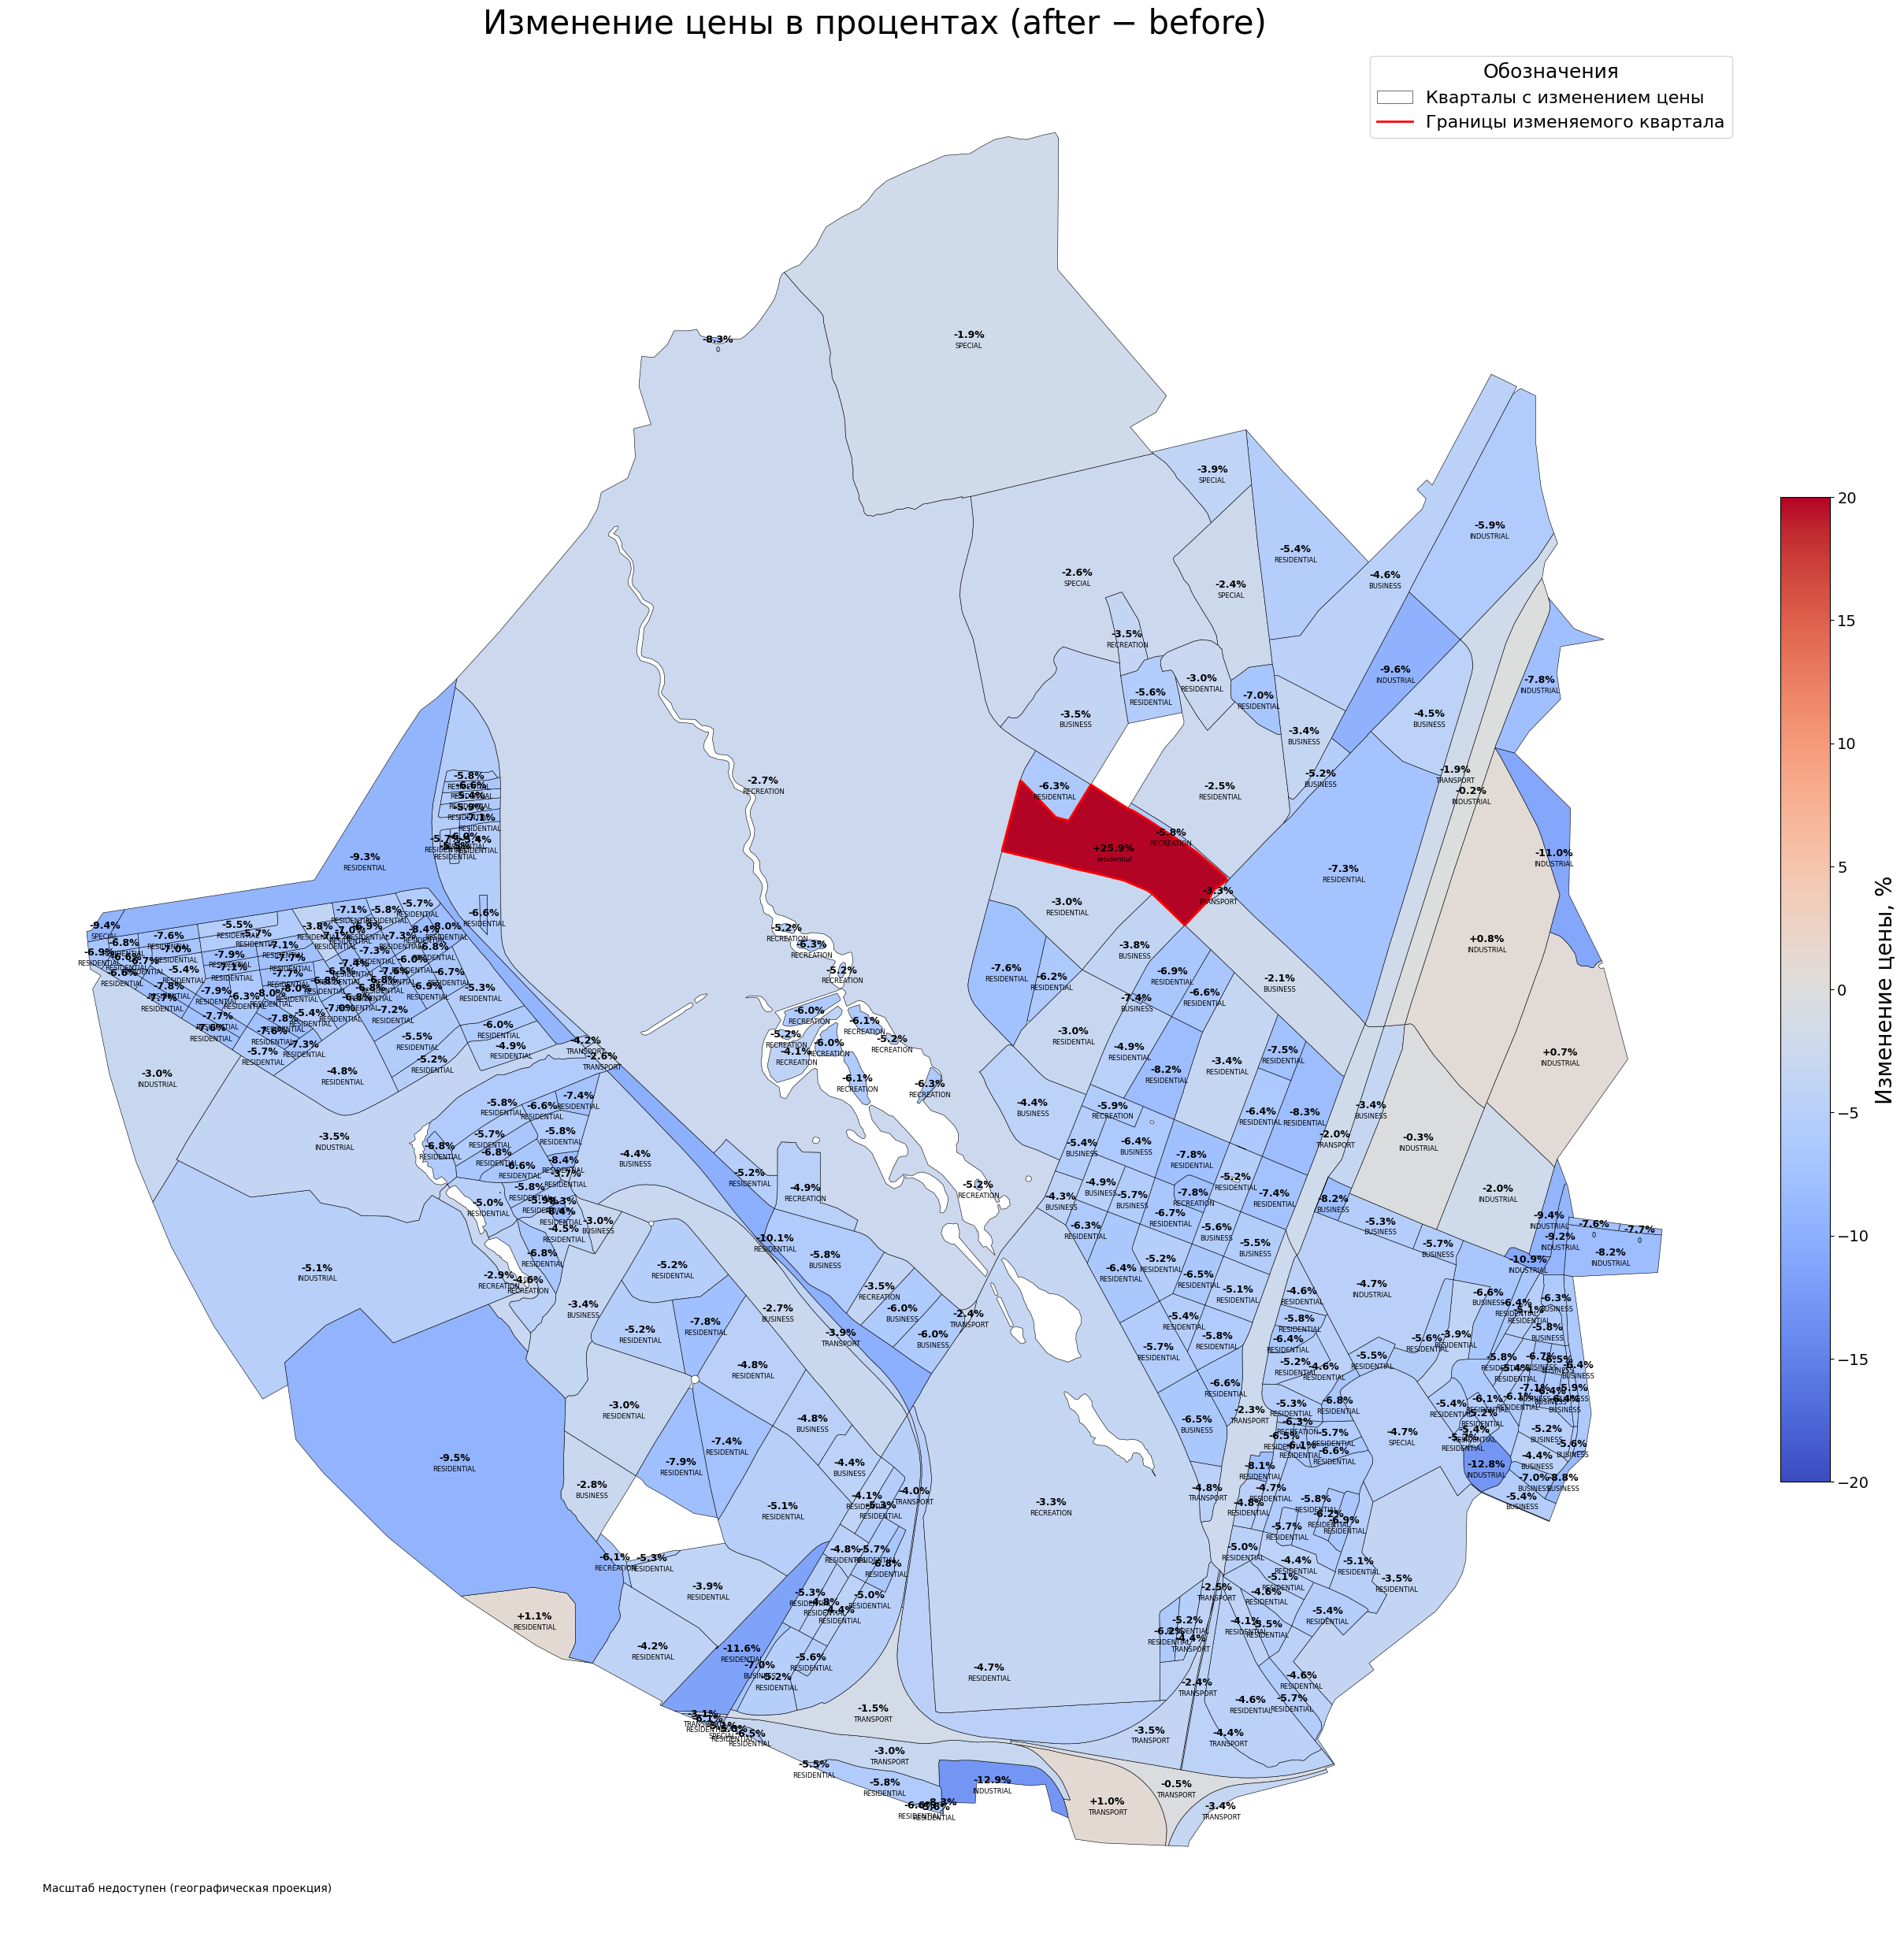

In [ ]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)


# Сравнение статзначимости фичей двух парето-фронтов

In [147]:
import pandas as pd

path = "/Users/andreyfeduhin/Urbanomy-data/data/pareto_front.jsonl"

df = pd.read_json(path, lines=True)




#params_df_llm = pd.json_normalize(df["params_repaired"])
#params_df_llm
params_df_llm = df[['land_value_gain', 'investor_npv']]

In [148]:
import pandas as pd

path = "/Users/andreyfeduhin/Urbanomy-data/data/no_llm_pareto_front.jsonl"

df = pd.read_json(path, lines=True)




#params_df_nollm = pd.json_normalize(df["params_repaired"])
params_df_nollm = df[['land_value_gain', 'investor_npv']]

In [149]:
import pandas as pd

import numpy as np

from scipy.stats import ttest_ind, mannwhitneyu

def compare_numeric_distributions(

    df1: pd.DataFrame,

    df2: pd.DataFrame,

    alpha=0.05,

    test="auto"

):

    """

    Сравнение числовых признаков между двумя датафреймами.

    Parameters

    ----------

    df1, df2 : DataFrame

    alpha : significance level

    test : "auto" | "ttest" | "mannwhitney"

    Returns

    -------

    DataFrame с p-value и выводом значимости

    """

    # только числовые признаки

    num_cols = df1.select_dtypes(include=np.number).columns.intersection(

        df2.select_dtypes(include=np.number).columns

    )

    results = []

    for col in num_cols:

        x = df1[col].dropna()

        y = df2[col].dropna()

        if len(x) == 0 or len(y) == 0:

            continue

        if test == "ttest":

            stat, p = ttest_ind(x, y, equal_var=False)

        elif test == "mannwhitney":

            stat, p = mannwhitneyu(x, y, alternative="two-sided")

        else:

            # auto → используем более робастный тест

            stat, p = mannwhitneyu(x, y, alternative="two-sided")

        results.append({

            "feature": col,

            "statistic": stat,

            "p_value": p,

            "significant": p < alpha

        })

    return pd.DataFrame(results).sort_values("p_value")

In [150]:
compare_numeric_distributions(params_df_llm, params_df_nollm, alpha=0.05, test="auto")

,feature,statistic,p_value,significant
0,land_value_gain,36.0,0.002409,True
1,investor_npv,83.0,0.273919,False


In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_feature_shift(df1, df2, top_n=20, normalize=True):
    """
    Показывает, как меняются числовые признаки между df1 → df2
    """

    num_cols = df1.select_dtypes(include=np.number).columns.intersection(
        df2.select_dtypes(include=np.number).columns
    )

    shifts = []

    for col in num_cols:

        x = df1[col].dropna()
        y = df2[col].dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        mean1 = x.mean()
        mean2 = y.mean()

        delta = mean2 - mean1

        # нормировка (effect size через std pooled)
        if normalize:
            pooled_std = np.sqrt((x.var() + y.var()) / 2)
            if pooled_std != 0:
                delta = delta / pooled_std

        shifts.append((col, delta))


    shift_df = pd.DataFrame(shifts, columns=["feature", "shift"])

    shift_df = shift_df.sort_values("shift", key=np.abs, ascending=False).head(top_n)


    # --- plot ---
    plt.figure(figsize=(10, 6))

    colors = ["red" if v < 0 else "green" for v in shift_df["shift"]]

    plt.barh(
        shift_df["feature"][::-1],
        shift_df["shift"][::-1],
        color=colors[::-1]
    )

    plt.axvline(0, color="black", linewidth=1)

    plt.xlabel("Shift (df2 - df1, normalized)" if normalize else "Mean difference")
    plt.title("Feature distribution shift (directional)")
    plt.tight_layout()
    plt.show()

    return shift_df

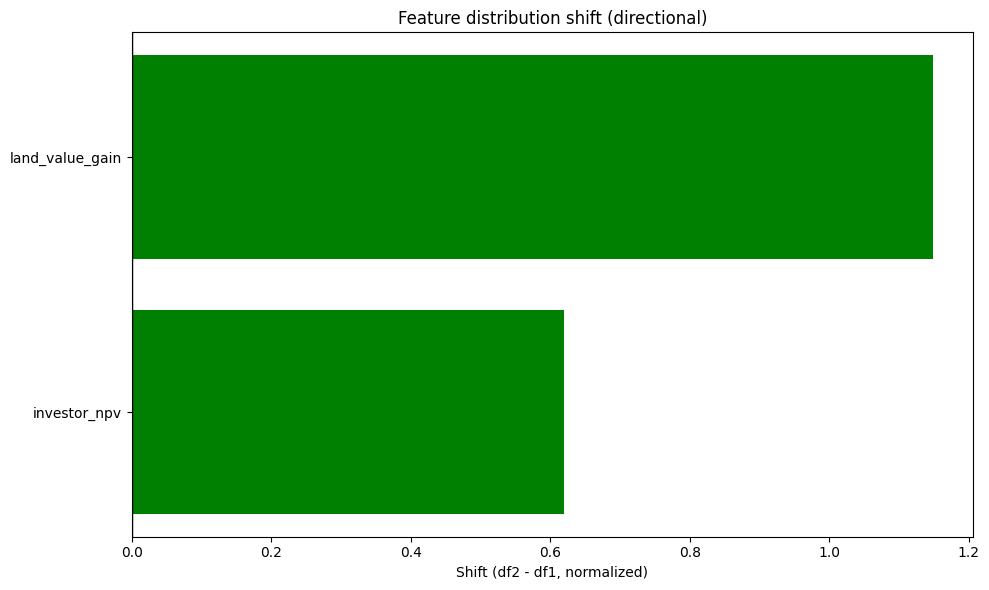

,feature,shift
0,land_value_gain,1.148279
1,investor_npv,0.620227


In [153]:
plot_feature_shift(params_df_llm, params_df_nollm, top_n=20, normalize=True)